In [115]:
# Import all the packages required

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load data
file_path = "/Users/anil.kharde/Documents/GitHub/Predicting-Farmer-Income-India/data/Pearl Challenge data with dictionary_For_Share_v4.xlsx"  # Update with your actual file path
df_train = pd.read_excel(file_path, sheet_name="TrainData")
df_test = pd.read_excel(file_path, sheet_name="TestData")

# Trim column names (remove spaces at the start, end, and replace multiple spaces with a single space)
df_train.columns = df_train.columns.str.strip().str.replace(r'\s+', ' ', regex=True)
df_test.columns = df_test.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Convert all object (string) columns to uppercase and remove extra spaces
df_train = df_train.apply(lambda x: x.str.upper().str.strip() if x.dtype == "object" else x)
df_test = df_test.apply(lambda x: x.str.upper().str.strip() if x.dtype == "object" else x)

In [3]:
df_train.head()

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1002818465057450,MADHYA PRADESH,CENTRAL,M,BARELI,464668,RAISEN,SEONI,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,97.24,19.50,0.95,22.380262,33.527178,POOR,0.773129,0.00,1360000
1,1003667148159900,MADHYA PRADESH,CENTRAL,M,MUNGAOLI,473443,ASHOKNAGAR,AAKSI,M,"24.5403206,78.0164869",...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,95.31,20.69,0.93,28.700358,43.769803,AVERAGE,0.199800,0.00,850000
2,1012300674433870,BIHAR,EAST,M,BANDRA,848125,MUZAFFARPUR,NAMAPUR,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.96,16.76,0.97,24.630262,37.173626,POOR,0.454140,0.00,807200
3,1013472263587380,MADHYA PRADESH,CENTRAL,M,MALHARGARH,458556,MANDSAUR,BILLAUD,M,NaN,...,CENTRAL HIGHLANDS ( MALWA ) GUJARAT PLAIN AND...,90.05,22.44,0.95,19.493313,28.848462,POOR,0.657040,0.00,500000
4,1019525480704050,MAHARASHTRA,WEST,M,RENAPUR,413527,LATUR,RENAPUR,M,NaN,...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,94.64,21.48,0.98,31.836367,48.852156,AVERAGE,0.235615,2.49,558000


In [4]:
df_test.head()

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Type of water bodies in hectares 2020,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm)
0,576972022499073,KARNATAKA,SOUTH,M,TUMAKURU,572102,TUMKUR,TUMKUR,M,"13.3173175,77.1240408",...,['WATER'],EASTERN GHATS AND TAMIL NADU UPLANDS AND DECCA...,92.35,23.34,0.97,34.633257,53.384919,GOOD,0.000118,8.85
1,979235081831136,HARYANA,NORTH,M,KALKA,133302,PANCHKULA,KALKA,M,"30.4749107,77.1320795",...,[NONE],NORTHERN PLAIN HOT SUBHUMID (DRY) ECO-REGION,43.91,12.77,0.94,32.964252,50.680057,GOOD,0.000268,43.23
2,176490610549774,HARYANA,NORTH,M,PINJORE,134102,PANCHKULA,KALKA,M,NaN,...,[NONE],NORTHERN PLAIN HOT SUBHUMID (DRY) ECO-REGION,43.91,12.77,0.94,32.964252,50.680057,GOOD,0.000268,43.23
3,977021407171384,HARYANA,NORTH,M,PINJORE,134102,PANCHKULA,KALKA,S,NaN,...,[NONE],NORTHERN PLAIN HOT SUBHUMID (DRY) ECO-REGION,43.91,12.77,0.94,32.964252,50.680057,GOOD,0.000268,43.23
4,1334154133262320,HARYANA,NORTH,M,PINJORE,134102,PANCHKULA,KALKA,M,"30.7982131,76.9209035",...,[NONE],NORTHERN PLAIN HOT SUBHUMID (DRY) ECO-REGION,43.91,12.77,0.94,32.964252,50.680057,GOOD,0.000268,43.23




#### Data Preparation and Feature Engineering

In [5]:
target_col = 'Target_Variable/Total Income'

In [6]:
cols_to_drop = []
cols_to_OHE = []
cols_to_transform = []

In [7]:
df_train[target_col].describe()

count    5.330600e+04
mean     1.376126e+06
std      2.647189e+07
min      0.000000e+00
25%      7.150000e+05
50%      9.500000e+05
75%      1.295250e+06
max      6.000000e+09
Name: Target_Variable/Total Income, dtype: float64

In [8]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def plot_target_col_distribution(df, col):
    """Plot histogram, KDE, and boxplot for a given column."""
    plt.figure(figsize=(16, 6))

    # Histogram & KDE Plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=50, kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot to detect outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')

    plt.show()

def analyse_target_col_distribution(df, col):
    print(f"\nAnalyzing '{col}':")
    data = df[col].dropna()  # Drop missing values if any
    
    # Compute Skewness & Kurtosis
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    
    print(f"  Skewness: {skewness:.3f}")
    print(f"  Kurtosis: {kurtosis:.3f}")

    plot_target_col_distribution(df, col)


def log_transform(df, col):
    """Applies log transformation to the specified columns."""
    df[col] = np.log1p(df[col])  # log(1 + x) to handle zero values
    return df


Analyzing 'Target_Variable/Total Income':
  Skewness: 219.085
  Kurtosis: 49484.675


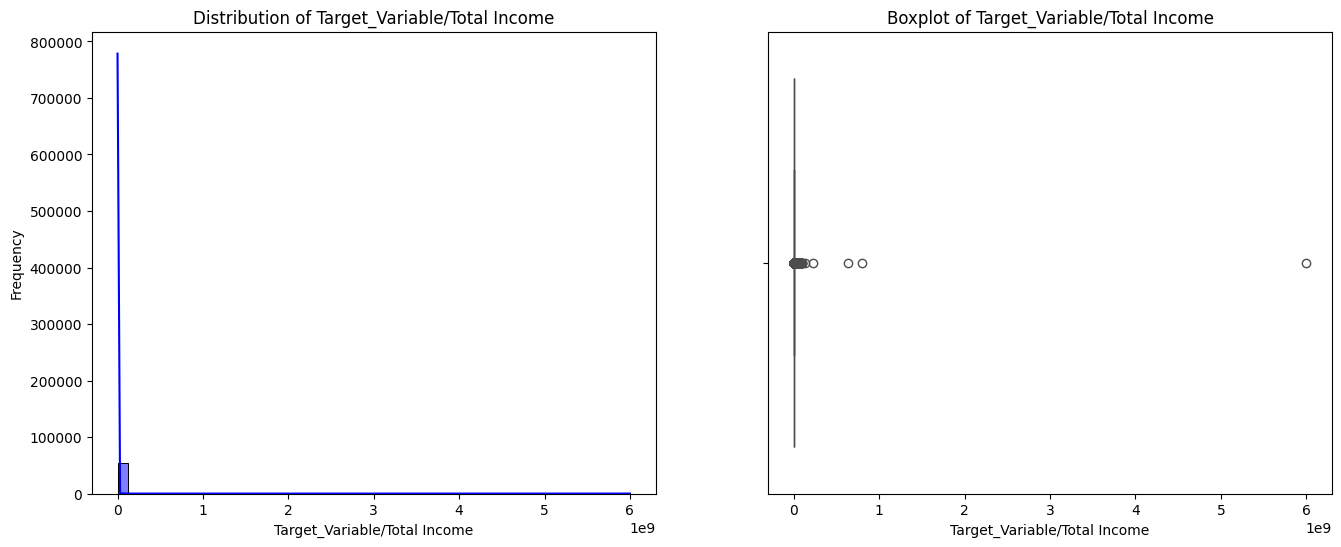

In [9]:
analyse_target_col_distribution(df_train, target_col)

In [10]:
df_train = log_transform(df_train, target_col)


Analyzing 'Target_Variable/Total Income':
  Skewness: -0.263
  Kurtosis: 56.699


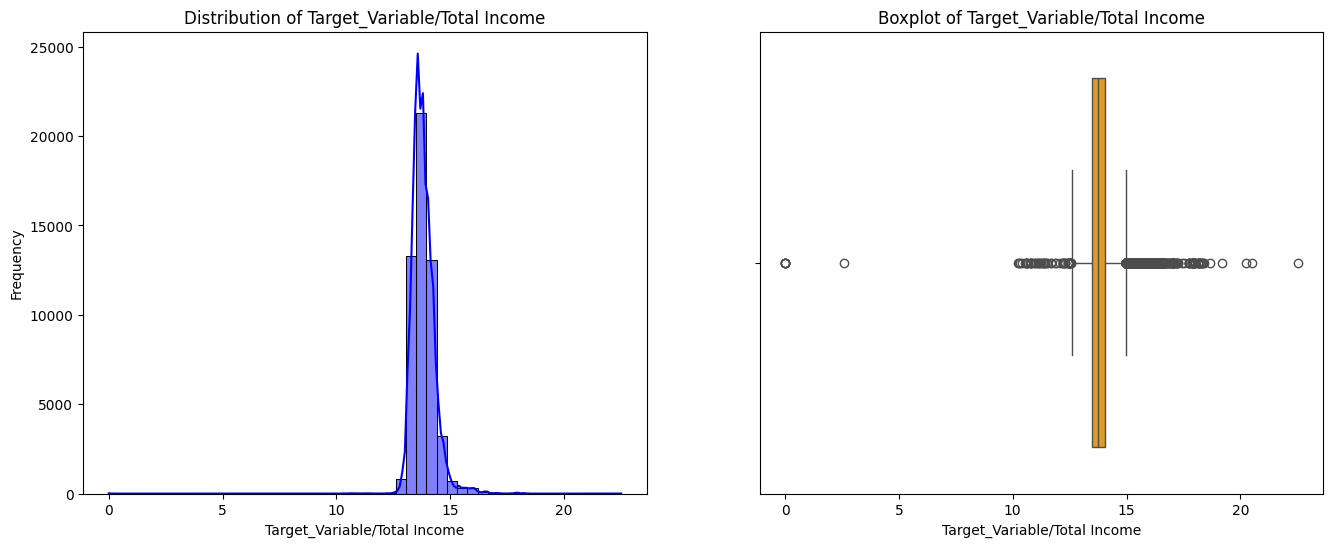

In [11]:
analyse_target_col_distribution(df_train, target_col)

In [12]:
df_train[target_col].describe()  ## Target variable looks approximately normal

count    53306.000000
mean        13.818417
std          0.528260
min          0.000000
25%         13.480039
50%         13.764218
75%         14.074215
max         22.515025
Name: Target_Variable/Total Income, dtype: float64


#### Geopgraphic columns

    Target Encoding 

        DISTRICT (405)- target encoding with smoothing over state mean
        CITY - target encoding with smoothing over district mean
        VILLAGE - target encoding with smoothing over city mean
        Zipcode - Split into Zone, Sub-zone and Sorting District
            The first digit indicates the zone. There are nine zones in India. 
            The second digit indicates the sub-zone. 
            The third digit, along with the first two, indicates the sorting district. 
            The last three digits indicate the delivery post office. 
    
    OHE

        State - 17 states ==> Low freq convert to Other ==> OHE
        REGION - 5 Regions ==> OHE
        Address type - 3 categoris + Blank >30%  ==> Drop
        Location - Lot of missing values >30%  ==> Drop (We can impute this column with lat and long using address, zipcode,etc)

        
#### Personal demograpics

     MARITAL_STATUS - 3 categories ==> 1 category has 4 rows, put in M category ==> Convert to Bool
     Ownership - 3 categories + Blanks ==> Unknown ==> OHE
     
    
    

In [13]:
# from sklearn.preprocessing import StandardScaler

def target_encoding_with_smoothing_2col(train, test, cat_col1, cat_col2, target_col, m=5):
    """
    Apply target encoding with smoothing to cat_col1, considering cat_col2 level influence on target_col.

    Parameters:
    df (pd.DataFrame): Input dataframe.
    cat_col1 (str): First categorical column (e.g., 'CITY').
    cat_col2 (str): Second categorical column (e.g., 'DISTRICT').
    target_col (str): Target numeric column (e.g., 'INCOME').
    m (int): Smoothing factor.

    Returns:
    pd.DataFrame: Dataframe with additional encoded column for cat_col1.
    """

    # Compute Global Mean
    global_mean = train[target_col].mean()

    # Compute cat_col2 Level Mean (e.g., District-Level Mean Income)
    col2_mean = train.groupby(cat_col2)[target_col].mean()

    # Compute cat_col1-Level Statistics within cat_col2
    cat_stats = train.groupby([cat_col1, cat_col2])[target_col].agg(['count', 'mean']).reset_index()


    # Apply Smoothing Formula
    cat_stats[f'Encoded_{cat_col1}'] = (cat_stats['count'] * cat_stats['mean'] + m * cat_stats[cat_col2].map(col2_mean)) / (cat_stats['count'] + m)

    # scaler = StandardScaler()
    # cat_stats[f'Encoded_{cat_col1}'] = scaler.fit_transform(cat_stats[[f'Encoded_{cat_col1}']])

    # Merge Encoded Values into Original DataFrame
    train = train.merge(cat_stats[[cat_col1, cat_col2, f'Encoded_{cat_col1}']], on=[cat_col1, cat_col2], how='left')
    test = test.merge(cat_stats[[cat_col1, cat_col2, f'Encoded_{cat_col1}']], on=[cat_col1, cat_col2], how='left')

    # Compute cat_col1 Mean for Fallback
    cat1_mean = train.groupby(cat_col1)[target_col].mean()

    # Fill Missing Values in Test
    test[f'Encoded_{cat_col1}'] = test[f'Encoded_{cat_col1}'].fillna(test[cat_col1].map(cat1_mean))  # Fallback to cat_col1 mean
    test[f'Encoded_{cat_col1}'] = test[f'Encoded_{cat_col1}'].fillna(global_mean)  # Fallback to global mean

    return train, test

def target_encoding_with_smoothing_1col(train, test, cat_col, target_col, m=5):
    """
    Apply target encoding with smoothing to a categorical column.

    Parameters:
    train (pd.DataFrame): Training dataset.
    test (pd.DataFrame): Test dataset.
    cat_col (str): Categorical column to encode (e.g., 'Occupation').
    target_col (str): Target numeric column (e.g., 'Income').
    m (int): Smoothing factor to control the impact of global mean.

    Returns:
    pd.DataFrame, pd.DataFrame: Train and test datasets with encoded column.
    """
    # Compute global mean of the target variable
    global_mean = train[target_col].mean()

    # Compute category-level statistics
    category_stats = train.groupby(cat_col)[target_col].agg(['count', 'mean'])

    # Apply smoothing formula
    category_stats[f'Encoded_{cat_col}'] = (category_stats['count'] * category_stats['mean'] + m * global_mean) / (category_stats['count'] + m)

    # scaler = StandardScaler()
    # category_stats[f'Encoded_{cat_col}'] = scaler.fit_transform(category_stats[[f'Encoded_{cat_col}']])

    # Merge encoded values into train and test datasets
    train = train.merge(category_stats[[f'Encoded_{cat_col}']], left_on=cat_col, right_index=True, how='left')
    test = test.merge(category_stats[[f'Encoded_{cat_col}']], left_on=cat_col, right_index=True, how='left')

    # Fill missing values in the test set
    test[f'Encoded_{cat_col}'] = test[f'Encoded_{cat_col}'].fillna(global_mean)  
    
    return train, test


In [14]:
# Apply Target Encoding District <--> State
df_train, df_test = target_encoding_with_smoothing_2col(df_train, df_test, 'DISTRICT', 'State', target_col, m=5)

In [15]:
# Apply Target Encoding City <--> District
df_train, df_test = target_encoding_with_smoothing_2col(df_train, df_test, 'CITY', 'DISTRICT', target_col, m=5)

In [16]:
# Apply Target Encoding Village <--> City
df_train, df_test = target_encoding_with_smoothing_2col(df_train, df_test, 'VILLAGE', 'CITY', target_col, m=5)

In [17]:
cols_to_drop.extend(["FarmerID","DISTRICT","CITY","VILLAGE"]) ## maintain the list and drop at the end

In [18]:
def extract_zip_details_from_df(train, test, zip_column):
    """
    Extracts zone, sub-zone, and sorting district from an Indian ZIP code column in a DataFrame.

    Parameters:
    df (pd.DataFrame): Input DataFrame containing ZIP codes.
    zip_column (str): Column name containing the 6-digit Indian postal codes.

    Returns:
    pd.DataFrame: DataFrame with new columns for Zone, Sub-zone, and Sorting District.
    """
    def extract_zip_details(zipcode):
        zipcode = str(zipcode).strip()  # Ensure it's a string and remove any spaces
        if len(zipcode) != 6 or not zipcode.isdigit():
            return pd.NA, pd.NA, pd.NA  # Handle invalid ZIP codes

        zone = int(zipcode[0])  # First digit - Zone
        sub_zone = int(zipcode[1])  # Second digit - Sub-zone
        sorting_district = int(zipcode[:3])  # First three digits - Sorting district

        return zone, sub_zone, sorting_district

    # Apply function and expand into multiple columns
    train[['Zone', 'Sub-zone', 'Sorting District']] = train[zip_column].apply(lambda x: pd.Series(extract_zip_details(x)))
    test[['Zone', 'Sub-zone', 'Sorting District']] = test[zip_column].apply(lambda x: pd.Series(extract_zip_details(x)))
    
    train,test = target_encoding_with_smoothing_1col(train, test, "Zone", target_col, m=5)
    train,test = target_encoding_with_smoothing_2col(train, test, "Sub-zone", "Zone", target_col,  m=5)
    train,test = target_encoding_with_smoothing_2col(train, test, "Sorting District", "Sub-zone", target_col,  m=5)
    
    return train, test


# Apply function
df_train, df_test = extract_zip_details_from_df(df_train, df_test, 'Zipcode')


In [19]:
cols_to_drop.append('Zipcode')

#### State Column

17 States

    MADHYA PRADESH    15959
    MAHARASHTRA        8712
    TELANGANA          7865
    KARNATAKA          7497
    ANDHRA PRADESH     4436
    UTTAR PRADESH      2644
    BIHAR              1407
    HARYANA            1066
    ODISHA             1013
    CHATTISGARH         880
    WEST BENGAL         650
    GUJARAT             604
    PUNJAB              276
    JHARKHAND           229
    ASSAM                42
    CHANDIGARH           23
    RAJASTHAN             3

Convert low freq state <100 to "Other" and perform one hot encoding


In [20]:
df_train["State"].value_counts()

State
MADHYA PRADESH    15959
MAHARASHTRA        8712
TELANGANA          7865
KARNATAKA          7497
ANDHRA PRADESH     4436
UTTAR PRADESH      2644
BIHAR              1407
HARYANA            1066
ODISHA             1013
CHATTISGARH         880
WEST BENGAL         650
GUJARAT             604
PUNJAB              276
JHARKHAND           229
ASSAM                42
CHANDIGARH           23
RAJASTHAN             3
Name: count, dtype: int64

In [21]:
df_test["State"].value_counts()

State
MADHYA PRADESH    3028
MAHARASHTRA       1701
TELANGANA         1457
KARNATAKA         1355
ANDHRA PRADESH     848
UTTAR PRADESH      513
BIHAR              267
HARYANA            203
ODISHA             186
CHATTISGARH        163
GUJARAT            113
WEST BENGAL         90
PUNJAB              40
JHARKHAND           28
ASSAM                5
CHANDIGARH           3
Name: count, dtype: int64

In [20]:
df_train["State"] = df_train["State"].map(lambda x: x if df_train["State"].value_counts()[x] >= 100 else "Other") # "ASSAM", "CHANDIGARH", "RAJASTHAN" ==> "Other"

In [21]:
df_test["State"]=df_test["State"].map(lambda x: "Other" if x in ["ASSAM", "CHANDIGARH", "RAJASTHAN"] else x)

In [22]:
cols_to_OHE.append("State")

In [23]:
df_train["REGION"].value_counts()

REGION
SOUTH      19798
CENTRAL    16744
WEST        9411
NORTH       4012
EAST        3341
Name: count, dtype: int64

In [24]:
cols_to_OHE.append("REGION")

In [25]:
df_train['SEX'].unique()

array(['M', 'F'], dtype=object)

In [26]:
df_train['SEX'].value_counts()

SEX
M    48098
F     5208
Name: count, dtype: int64

In [27]:
df_test['SEX'].unique()

array(['M', 'F', 'O'], dtype=object)

In [28]:
df_test['SEX'].value_counts()

SEX
M    9041
F     957
O       2
Name: count, dtype: int64

In [29]:
mode_value = df_train['SEX'].mode()[0]  ### Replace Other category with mode

In [30]:
mode_value

'M'

In [31]:
df_train['SEX'] = df_train['SEX'].map({'M': 1, 'F': 0})
df_test['SEX'] = df_test['SEX'].map({'M': 1, 'F': 0, 'O':1}) ### Replace Other category with mode

In [32]:
df_train['MARITAL_STATUS'].value_counts()

MARITAL_STATUS
M     49057
S      4245
NK        4
Name: count, dtype: int64

In [33]:
df_test['MARITAL_STATUS'].value_counts()

MARITAL_STATUS
M    9188
S     812
Name: count, dtype: int64

In [34]:
df_train['MARITAL_STATUS'] = df_train['MARITAL_STATUS'].map({'M': 1, 'S': 0,'NK':1})
df_test['MARITAL_STATUS'] = df_test['MARITAL_STATUS'].map({'M': 1, 'S': 0, 'NK':1})

In [35]:
cols_to_drop.extend(['Zone','Sub-zone','Sorting District'])

#### Missing Value Imputation

In [36]:
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print("Missing Values Summary:\n", missing_summary[missing_summary['Missing Values'] > 0])

Missing Values Summary:
                                                     Missing Values  Percentage
Location                                                     18950   35.549469
Address type                                                 18950   35.549469
Ownership                                                    18950   35.549469
Avg_Disbursement_Amount_Bureau                               23024   43.192136
Total_Land_For_Agriculture                                      78    0.146325
Perc_of_house_with_6plus_room                                  185    0.347053
Women_15_19_Mothers_or_Pregnant_at_time_of_survey              185    0.347053
perc_of_pop_living_in_hh_electricity                           185    0.347053
perc_Households_with_Pucca_House_That_Has_More_...             185    0.347053
mat_roof_Metal_GI_Asbestos_sheets                              185    0.347053
perc_of_Wall_material_with_Burnt_brick                         185    0.347053
Households_with_improved_Sa

In [37]:
missing_values = df_test.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print("Missing Values Summary:\n", missing_summary[missing_summary['Missing Values'] > 0])

Missing Values Summary:
                                                     Missing Values  Percentage
Location                                                      3575    6.706562
Address type                                                  3575    6.706562
Ownership                                                     3575    6.706562
Avg_Disbursement_Amount_Bureau                                4269    8.008479
Total_Land_For_Agriculture                                      20    0.037519
Perc_of_house_with_6plus_room                                   33    0.061907
Women_15_19_Mothers_or_Pregnant_at_time_of_survey               33    0.061907
perc_of_pop_living_in_hh_electricity                            33    0.061907
perc_Households_with_Pucca_House_That_Has_More_...              33    0.061907
mat_roof_Metal_GI_Asbestos_sheets                               33    0.061907
perc_of_Wall_material_with_Burnt_brick                          33    0.061907
Households_with_improved_Sa

In [38]:
# Drop columns with missing value > 30%
cols_to_drop.append("Location")
cols_to_drop.append("Avg_Disbursement_Amount_Bureau")
cols_to_drop.append("Address type")
cols_to_drop.append("Ownership")

### Column	Imputation Strategy	Reason: 

Address type  ==> DROP

Ownership ==> DROP      

Avg_Disbursement_Amount_Bureau ==> DROP

Total_Land_For_Agriculture ==> Median ==> Land values tend to be skewed, and median is more robust to outliers.

Perc_of_house_with_6plus_room ==> Mean ==> This is a percentage, and mean imputation works well for such continuous variables.

Women_15_19_Mothers_or_Pregnant_at_time_of_survey ==> Mean ==> It’s a demographic percentage, so mean is a reasonable estimate.

perc_of_pop_living_in_hh_electricity ==> Mean ==> Percentage-based metric, mean is appropriate.

perc_Households_with_Pucca_House_That_Has_More_... ==> Mean ==> Similar to above, use mean.

mat_roof_Metal_GI_Asbestos_sheets ==> Mode ==> This is likely a categorical or binary variable, so use mode.

perc_of_Wall_material_with_Burnt_brick ==> Mean ==> Another percentage metric, mean imputation works.

Households_with_improved_Sanitation_Facility ==> Mean ==> Sanitation facility percentages are best imputed using mean.

perc_Households_do_not_have_KCC_With_The_Credit... ==> Mean ==> Another percentage-based variable; mean is best.


In [ ]:

#### To fill missing  location values

# from geopy.geocoders import Nominatim
# import time

# geolocator = Nominatim(user_agent="anilkharde786@gmail.com")  # Use a valid email as User-Agent

# def get_lat_lon_osm(zipcode, country="India"):
#     """Get latitude & longitude from ZIP using OpenStreetMap (Nominatim)"""
#     time.sleep(1)  # To avoid rate limits (1 request per second)
#     location = geolocator.geocode({"postalcode": zipcode, "country": country}, exactly_one=True)
#     if location:
#         return location.latitude, location.longitude
#     return None, None

# # Example usage
# zipcode = "560064"  # Connaught Place, Delhi
# lat, lon = get_lat_lon_osm(zipcode)
# print(f"Latitude: {lat}, Longitude: {lon}")

In [39]:
from sklearn.impute import SimpleImputer

# Define imputation strategies
impute_median = SimpleImputer(strategy='median')
impute_mean = SimpleImputer(strategy='mean')
impute_mode = SimpleImputer(strategy='most_frequent')

# List of columns to impute
mean_cols = [
    'Perc_of_house_with_6plus_room', 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
    'perc_of_pop_living_in_hh_electricity', 'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
    'perc_of_Wall_material_with_Burnt_brick', 'Households_with_improved_Sanitation_Facility',
    'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k'
]

mode_cols = ['mat_roof_Metal_GI_Asbestos_sheets']

median_cols = ["Total_Land_For_Agriculture"]

# Fit imputer on train data only
impute_mean.fit(df_train[mean_cols])
impute_mode.fit(df_train[mode_cols])
impute_median.fit(df_train[median_cols])


# Transform train and test datasets
df_train[mean_cols] = impute_mean.transform(df_train[mean_cols])
df_test[mean_cols] = impute_mean.transform(df_test[mean_cols])  # Uses train mean

df_train[mode_cols] = impute_mode.transform(df_train[mode_cols])
df_test[mode_cols] = impute_mode.transform(df_test[mode_cols])  # Uses train mode

df_train[median_cols] = impute_median.transform(df_train[median_cols])
df_test[median_cols] = impute_median.transform(df_test[median_cols])  # Uses train median


In [40]:
missing_values = df_train.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print("Missing Values Summary:\n", missing_summary[missing_summary['Missing Values'] > 0])

Missing Values Summary:
                                 Missing Values  Percentage
Location                                 18950   35.549469
Address type                             18950   35.549469
Ownership                                18950   35.549469
Avg_Disbursement_Amount_Bureau           23024   43.192136


In [41]:
missing_values = df_test.isnull().sum()
missing_percent = (missing_values / len(df_train)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print("Missing Values Summary:\n", missing_summary[missing_summary['Missing Values'] > 0])

Missing Values Summary:
                                 Missing Values  Percentage
Location                                  3575    6.706562
Address type                              3575    6.706562
Ownership                                 3575    6.706562
Avg_Disbursement_Amount_Bureau            4269    8.008479


In [42]:
 cols_analysis = [
    'Perc_of_house_with_6plus_room', 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
    'perc_of_pop_living_in_hh_electricity', 'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
    'perc_of_Wall_material_with_Burnt_brick', 'Households_with_improved_Sanitation_Facility',
    'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k','mat_roof_Metal_GI_Asbestos_sheets',"Total_Land_For_Agriculture"
]

cols_to_transform.extend(cols_analysis)

In [40]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Copy the dataset before imputation for comparison
# X_train_before = X_train.copy()

# # Apply KNN Imputation
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# X_train[['Avg_Disbursement_Amount_Bureau']] = imputer.fit_transform(X_train[['Avg_Disbursement_Amount_Bureau']])

# Plot histograms
# plt.figure(figsize=(10, 5))
# sns.histplot(X_train_before['Avg_Disbursement_Amount_Bureau'], bins=30, kde=True, color='red', label='Before Imputation', alpha=0.6)
# # sns.histplot(X_train['Avg_Disbursement_Amount_Bureau'], bins=30, kde=True, color='blue', label='After KNN Imputation', alpha=0.6)

# plt.legend()
# plt.title("Distribution of Avg_Disbursement_Amount_Bureau Before & After KNN Imputation")
# plt.xlabel("Avg_Disbursement_Amount_Bureau")
# plt.ylabel("Frequency")
# plt.show()

### Categorical Vs Categorical Correlation
#### Drop Cols with high Cramér's V correlation >0.9

Set 1:

    Columns:
        Rabi Seasons Type of soil in 2020
        Rabi Seasons Type of soil in 2021
        Rabi Seasons Type of soil in 2022
        Kharif Seasons  Type of soil in 2022
        Kharif Seasons Type of soil in 2020
        Kharif Seasons Type of soil in 2021

    Result:
       
        ✅ Keep:

                Rabi Seasons Type of soil in 2020
                Kharif Seasons Type of soil in 2020

        ❌ Drop:

                Rabi Seasons Type of soil in 2021
                Rabi Seasons Type of soil in 2022
                Kharif Seasons Type of soil in 2021
                Kharif Seasons Type of soil in 2022
    
Set 2: 

    Columns:

        Rabi Seasons Type of water bodies in hectares 2020
        Rabi Seasons Type of water bodies in hectares 2021
        Rabi Seasons Type of water bodies in hectares 2022
        Kharif Seasons Type of water bodies in hectares 2020
        Kharif Seasons Type of water bodies in hectares 2021
        Kharif Seasons  Type of water bodies in hectares 2022

    Result:
    
       ✅ Keep:

            Rabi Seasons Type of Water Bodies in Hectares 2020
            Kharif Seasons Type of Water Bodies in Hectares 2020
            Kharif Seasons Type of Water Bodies in Hectares 2021

       ❌ Drop:

            Rabi Seasons Type of Water Bodies in Hectares 2021
            Rabi Seasons Type of Water Bodies in Hectares 2022
            Kharif Seasons  Type of water bodies in hectares 2022

Set 3:

    Columns:

        Village category based on socio-economic parameters (Good, Average, Poor)
        K022-Village category based on socio-economic parameters (Good, Average, Poor)
        K022-Village category based on Agri parameters (Good, Average, Poor)
        R022-Village category based on Agri parameters (Good, Average, Poor)
        
    Result:

        ✅ Keep:
    
            Village category based on socio-economic parameters (Good, Average, Poor)
            K022-Village category based on Agri parameters (Good, Average, Poor)
            R022-Village category based on Agri parameters (Good, Average, Poor)
    
        ❌ Drop:
    
            K022-Village category based on socio-economic parameters (Good, Average, Poor)

Set 4:

    Columns: 
    
        Rabi Seasons Agro Ecological Sub Zone in 2020
        Rabi Seasons Agro Ecological Sub Zone in 2021
        Rabi Seasons Agro Ecological Sub Zone in 2022
    
        Kharif Seasons Agro Ecological Sub Zone in 2020
        Kharif Seasons Agro Ecological Sub Zone in 2021
        Kharif Seasons  Agro Ecological Sub Zone in 2022

    Result:

        ✅ Keep:
    
            Rabi Seasons Agro Ecological Sub Zone in 2020
            Kharif Seasons Agro Ecological Sub Zone in 2020
            Kharif Seasons Agro Ecological Sub Zone in 2021
    
        ❌ Drop:
    
            Rabi Seasons Agro Ecological Sub Zone in 2021
            Rabi Seasons Agro Ecological Sub Zone in 2022
            Kharif Seasons Agro Ecological Sub Zone in 2022
    



In [224]:
# Function to compute Cramér's V

import scipy.stats as stats

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = stats.chi2_contingency(contingency_table)
    n = len(x)
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def categorical_correlation(cols):
    # Compute pairwise Cramér's V
    results = {}
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = cramers_v(df_train[cols[i]], df_train[cols[j]])
            results[f"{cols[i]} vs {cols[j]}"] = v
    
    # Print the results
    for pair, v in results.items():
        # Interpretation
        if v < 0.1:
            corr = "Weak correlation ==>> No DROP"
        elif v < 0.9:
            corr = "Moderate correlation ==>> No DROP"
        else:
            corr = "Strong correlation ==>> DROP One"
            
        print(f"{pair}: Cramér's V = {v:.4f}, {corr}" )
        
        

In [230]:
cols = ["Rabi Seasons Type of soil in 2020",
        "Rabi Seasons Type of soil in 2021",
        "Rabi Seasons Type of soil in 2022",
        "Kharif Seasons  Type of soil in 2022",
        "Kharif Seasons Type of soil in 2020",
        "Kharif Seasons Type of soil in 2021"
       ]
categorical_correlation(cols)

Rabi Seasons Type of soil in 2020 vs Rabi Seasons Type of soil in 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2020 vs Rabi Seasons Type of soil in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2020 vs Kharif Seasons  Type of soil in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2020 vs Kharif Seasons Type of soil in 2020: Cramér's V = 0.8953, Moderate correlation ==>> No DROP
Rabi Seasons Type of soil in 2020 vs Kharif Seasons Type of soil in 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2021 vs Rabi Seasons Type of soil in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2021 vs Kharif Seasons  Type of soil in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of soil in 2021 vs Kharif Seasons Type of soil in 2020: Cramér's V = 0.8953, Moderate cor

In [233]:
cols = ["Rabi Seasons Type of water bodies in hectares 2020",
        "Rabi Seasons Type of water bodies in hectares 2021",
        "Rabi Seasons Type of water bodies in hectares 2022",
        "Kharif Seasons Type of water bodies in hectares 2020",
        "Kharif Seasons Type of water bodies in hectares 2021",
        "Kharif Seasons  Type of water bodies in hectares 2022"
       ]
categorical_correlation(cols)

Rabi Seasons Type of water bodies in hectares 2020 vs Rabi Seasons Type of water bodies in hectares 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of water bodies in hectares 2020 vs Rabi Seasons Type of water bodies in hectares 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of water bodies in hectares 2020 vs Kharif Seasons Type of water bodies in hectares 2020: Cramér's V = 0.8731, Moderate correlation ==>> No DROP
Rabi Seasons Type of water bodies in hectares 2020 vs Kharif Seasons Type of water bodies in hectares 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of water bodies in hectares 2020 vs Kharif Seasons  Type of water bodies in hectares 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of water bodies in hectares 2021 vs Rabi Seasons Type of water bodies in hectares 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Type of water bodie

In [232]:
cols = [
    "Rabi Seasons Agro Ecological Sub Zone in 2020",
    "Rabi Seasons Agro Ecological Sub Zone in 2021",
    "Rabi Seasons Agro Ecological Sub Zone in 2022",
    "Kharif Seasons Agro Ecological Sub Zone in 2020",
    "Kharif Seasons Agro Ecological Sub Zone in 2021",
    "Kharif Seasons  Agro Ecological Sub Zone in 2022"
]
categorical_correlation(cols)

Rabi Seasons Agro Ecological Sub Zone in 2020 vs Rabi Seasons Agro Ecological Sub Zone in 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Agro Ecological Sub Zone in 2020 vs Rabi Seasons Agro Ecological Sub Zone in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Agro Ecological Sub Zone in 2020 vs Kharif Seasons Agro Ecological Sub Zone in 2020: Cramér's V = 0.8980, Moderate correlation ==>> No DROP
Rabi Seasons Agro Ecological Sub Zone in 2020 vs Kharif Seasons Agro Ecological Sub Zone in 2021: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Agro Ecological Sub Zone in 2020 vs Kharif Seasons  Agro Ecological Sub Zone in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Agro Ecological Sub Zone in 2021 vs Rabi Seasons Agro Ecological Sub Zone in 2022: Cramér's V = 1.0000, Strong correlation ==>> DROP One
Rabi Seasons Agro Ecological Sub Zone in 2021 vs Kharif Seasons Agro Ecological Sub Zone in 

In [236]:
cols = [
    " Village category based on socio-economic parameters (Good, Average, Poor)",
    "K022-Village category based on socio-economic parameters (Good, Average, Poor)",
    "K022-Village category based on Agri parameters (Good, Average, Poor)",
    "R022-Village category based on Agri parameters (Good, Average, Poor)"
]
categorical_correlation(cols)

 Village category based on socio-economic parameters (Good, Average, Poor) vs K022-Village category based on socio-economic parameters (Good, Average, Poor): Cramér's V = 1.0000, Strong correlation ==>> DROP One
 Village category based on socio-economic parameters (Good, Average, Poor) vs K022-Village category based on Agri parameters (Good, Average, Poor): Cramér's V = 0.0485, Weak correlation ==>> No DROP
 Village category based on socio-economic parameters (Good, Average, Poor) vs R022-Village category based on Agri parameters (Good, Average, Poor): Cramér's V = 0.0773, Weak correlation ==>> No DROP
K022-Village category based on socio-economic parameters (Good, Average, Poor) vs K022-Village category based on Agri parameters (Good, Average, Poor): Cramér's V = 0.0485, Weak correlation ==>> No DROP
K022-Village category based on socio-economic parameters (Good, Average, Poor) vs R022-Village category based on Agri parameters (Good, Average, Poor): Cramér's V = 0.0773, Weak correlati

In [43]:
cols_drop_cat = ["Rabi Seasons Type of soil in 2021",
             "Rabi Seasons Type of soil in 2022",
             "Kharif Seasons Type of soil in 2021",
             "Kharif Seasons Type of soil in 2022",
             "Rabi Seasons Type of water bodies in hectares 2021",
             "Rabi Seasons Type of water bodies in hectares 2022",
             "Kharif Seasons Type of water bodies in hectares 2022",
             "K022-Village category based on socio-economic parameters (Good, Average, Poor)",
             "Rabi Seasons Agro Ecological Sub Zone in 2021",
             "Rabi Seasons Agro Ecological Sub Zone in 2022",
             "Kharif Seasons Agro Ecological Sub Zone in 2022"
            ]
cols_to_drop.extend(cols_drop_cat)

In [44]:
df_train["Rabi Seasons Type of soil in 2020"].value_counts()

Rabi Seasons Type of soil in 2020
MIXED RED AND BLACK SOILS                                               18352
DEEP BLACK SOILS (WITH SHALLOW AND MEDIUM BLACK SOILS AS INCLUSION)     13066
SHALLOW BLACK SOILS (WITH MEDIUM AND DEEP BLACK SOILS AS  INCLUSION)    11461
RED LOAMY SOILS                                                          4512
RED AND LATERITIC SOILS                                                  2446
COASTAL AND DELTAIC ALLUVIUM DERIVED SOILS                               1520
ALLUVIAL-DERIVED SOILS (WITH SALINE PHASES)                              1030
DESERT (SALINE) SOILS                                                     919
Name: count, dtype: int64

In [45]:
cat_cols_encode = [
            "Rabi Seasons Type of soil in 2020",
            "Kharif Seasons Type of soil in 2020",
            "Rabi Seasons Type of water bodies in hectares 2020",
            "Kharif Seasons Type of water bodies in hectares 2020",
            "Kharif Seasons Type of water bodies in hectares 2021",
            "Rabi Seasons Agro Ecological Sub Zone in 2020",
            "Kharif Seasons Agro Ecological Sub Zone in 2020",
            "Kharif Seasons Agro Ecological Sub Zone in 2021"
    
]

for cat_col in cat_cols_encode:
    df_train, df_test = target_encoding_with_smoothing_1col(df_train, df_test, cat_col, target_col, m=5)

In [46]:
cols_to_drop.extend(cat_cols_encode)
cols_to_OHE.extend(["Village category based on socio-economic parameters (Good, Average, Poor)",
            "K022-Village category based on Agri parameters (Good, Average, Poor)",
            "R022-Village category based on Agri parameters (Good, Average, Poor)"])
 

### 'Rabi Seasons Type of water bodies in hectares' Column transform (list of values)

In [47]:
### Tranformation of water bodies columns

water_bodies_cols = ["Rabi Seasons Type of water bodies in hectares 2020",
                      "Kharif Seasons Type of water bodies in hectares 2020",
                      "Kharif Seasons Type of water bodies in hectares 2021"]
                    

In [48]:
def clean_alt_list(list_):
    list_ = list_.replace(", ", "','")
    return list_
    
def water_bodies_df(train_df, test_df, cols):
    for col in cols:
        # Replace missing or empty values with 'Unknown'
        train_df[col] = train_df[col].apply(lambda x: "['Unknown']" if x == [None] or x == [] or x == '[None]' or x == '[NONE]' else x)
        test_df[col] = test_df[col].apply(lambda x: "['Unknown']" if x == [None] or x == [] or x == '[None]' or x == '[NONE]' else x)

        # Clean and convert string lists to actual lists
        train_df[col] = train_df[col].apply(clean_alt_list).apply(eval)
        test_df[col] = test_df[col].apply(clean_alt_list).apply(eval)

        # Get unique categories from the training set
        unique_items = train_df[col].explode().value_counts().index.tolist()

        # Ensure test data has only known categories; else, mark as "Unknown"
        test_df[col] = test_df[col].apply(lambda x: [item if item in unique_items else "Unknown" for item in x])

        # Create boolean encoding for train and test
        bool_dict_train = {col + "_" + item: train_df[col].apply(lambda x: int(item in x)) for item in unique_items}
        bool_dict_test = {col + "_" + item: test_df[col].apply(lambda x: int(item in x)) for item in unique_items}

        # Convert to DataFrame
        bool_df_train = pd.DataFrame(bool_dict_train)
        bool_df_test = pd.DataFrame(bool_dict_test)

        # Drop the 'Unknown' column if it exists
        if col + "_Unknown" in bool_df_train.columns:
            bool_df_train.drop(columns=[col + "_Unknown"], inplace=True)
        if col + "_Unknown" in bool_df_test.columns:
            bool_df_test.drop(columns=[col + "_Unknown"], inplace=True)

        # Concatenate boolean encoding with original dataframes
        train_df = pd.concat([train_df, bool_df_train], axis=1)
        test_df = pd.concat([test_df, bool_df_test], axis=1)

    return train_df, test_df

In [49]:
df_train,df_test = water_bodies_df(df_train, df_test,water_bodies_cols)

#### Numerical Vs Numerical Correlation


Set 1:

    Columns:
        Rabi Seasons Seasonal average groundwater thickness (cm) in 2022
        Rabi Seasons Seasonal average groundwater thickness (cm) in 2021
        Rabi Seasons Seasonal average groundwater thickness (cm) in 2020
        Kharif Seasons Seasonal average groundwater thickness (cm) in 2021
        Kharif Seasons Seasonal average groundwater thickness (cm) in 2020
        Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022

    Result:
        ✅ Keep:

            Kharif Seasons Seasonal average groundwater thickness (cm) in 2020
            Rabi Seasons Seasonal average groundwater thickness (cm) in 2020
        
        ❌ Drop:
        
            Rabi Seasons Seasonal average groundwater thickness (cm) in 2021
            Rabi Seasons Seasonal average groundwater thickness (cm) in 2022
            Kharif Seasons Seasonal average groundwater thickness (cm) in 2021
            Kharif Seasons Seasonal average groundwater thickness (cm) in 2022

Set 2:

    Columns:
        Village score based on socio-economic parameters (0 to 100)
        KO22-Village score based on socio-economic parameters (0 to 100)
        Village score based on socio-economic parameters (Non normalised)

    Result: 
        ✅ Keep:
    
            Village score based on socio-economic parameters (0 to 100)
    
        ❌ Drop:
    
            KO22-Village score based on socio-economic parameters (0 to 100)
            Village score based on socio-economic parameters (Non normalised)
    

Set 3:

    Columns:
        Kharif Seasons Kharif Season Irrigated area in 2020
        Kharif Seasons Kharif Season Irrigated area in 2021
        Kharif Seasons  Irrigated area in 2022
        Rabi Seasons  Season Irrigated area in 2022
        Rabi Seasons Kharif Season Irrigated area in 2021
        Rabi Seasons Kharif Season Irrigated area in 2020
    Result: 
        ✅ Keep:
    
            Kharif Seasons Kharif Season Irrigated area in 2020
            Kharif Seasons Kharif Season Irrigated area in 2021
            Kharif Seasons  Irrigated area in 2022
            Rabi Seasons Kharif Season Irrigated area in 2021
            Rabi Seasons Kharif Season Irrigated area in 2020
    
        ❌ Drop:
    
            Rabi Seasons  Season Irrigated area in 2022


Set 4:

    Columns:
        Rabi Seasons Agricultural performance in 2020
        Rabi Seasons Agricultural performance in 2021
        Rabi Seasons Agricultural performance in 2022
        Kharif Seasons Agricultural performance in 2021
        Kharif Seasons Agricultural performance in 2020
        Kharif Seasons  Agricultural performance in 2022
        
        Rabi Seasons Agricultural Score in 2020
        Rabi Seasons Agricultural Score in 2021
        Rabi Seasons Agricultural Score in 2022
        Kharif Seasons Agricultural Score in 2020
        Kharif Seasons Agricultural Score in 2021
        Kharif Seasons  Agricultural Score in 2022

    Result:
        
        ✅ Keep:

            All Columns

Set 5:

    Columns:
        Rabi Seasons Cropping density in 2020
        Rabi Seasons Cropping density in 2021
        Rabi Seasons Cropping density in 2022
        Kharif Seasons Cropping density in 2020
        Kharif Seasons Cropping density in 2021
        Kharif Seasons  Cropping density in 2022

    Result:
    
        ✅ Keep:
    
            Rabi Seasons Cropping density in 2020
            Rabi Seasons Cropping density in 2021
            Rabi Seasons Cropping density in 2022
            Kharif Seasons Cropping density in 2020
            Kharif Seasons  Cropping density in 2022
    
        ❌ Drop:

            Kharif Seasons Cropping density in 2021

Set 6:

    Columns:

        Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020
        Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021
        Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022
        Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020
        Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021
        Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022


        ✅ Keep:

            All Columns


Set 7:

    Columns:

        K021-Seasonal Average Rainfall (mm)
        K022-Seasonal Average Rainfall (mm)
        R021-Seasonal Average Rainfall (mm)
        R020-Seasonal Average Rainfall (mm)
        R022-Seasonal Average Rainfall (mm)
        
    ✅ Keep:

            All Columns




In [242]:
def numerical_correlation(num_cols, df, threshold=0.9):
    """
    Computes the Pearson correlation between numerical columns and suggests columns to drop.

    Parameters:
    df (pd.DataFrame): Input DataFrame.
    threshold (float): Correlation threshold to drop highly correlated columns.

    Returns:
    None (prints results)
    """

    # Select only numerical columns (int and float)
    # num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Compute correlation matrix
    corr_matrix = df[num_cols].corr().abs()

    # Store pairs of columns with high correlation
    to_drop = set()
    results = {}

    # Iterate through the upper triangle of the correlation matrix
    for i in range(len(num_cols)):
        for j in range(i + 1, len(num_cols)):
            col1, col2 = num_cols[i], num_cols[j]
            corr_value = corr_matrix.loc[col1, col2]

            # Store correlation results
            results[f"{col1} vs {col2}"] = corr_value

            # Check if correlation is above threshold
            if corr_value > threshold:
                to_drop.add(col2)  # Drop one of the correlated columns

    # Print correlation results
    for pair, v in results.items():
        if v < 0.1:
            corr = "Weak correlation ==>> No DROP"
        elif v < 0.9:
            corr = "Moderate correlation ==>> No DROP"
        else:
            corr = "Strong correlation ==>> DROP One"
        
        print(f"{pair}: Pearson's r = {v:.4f}, {corr}")

    print("\n✅ **Columns to Keep:**", [col for col in num_cols if col not in to_drop])
    print("❌ **Columns to Drop:**", list(to_drop))

    return list(to_drop)  # Returns a list of columns to drop

In [244]:
cols = [
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2022",
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2021",
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2020",
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2021",
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2020",
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2022"
]
numerical_correlation(cols, X_train)

Rabi Seasons Seasonal average groundwater thickness (cm) in 2022 vs Rabi Seasons Seasonal average groundwater thickness (cm) in 2021: Pearson's r = 0.9818, Strong correlation ==>> DROP One
Rabi Seasons Seasonal average groundwater thickness (cm) in 2022 vs Rabi Seasons Seasonal average groundwater thickness (cm) in 2020: Pearson's r = 0.9499, Strong correlation ==>> DROP One
Rabi Seasons Seasonal average groundwater thickness (cm) in 2022 vs Kharif Seasons Seasonal average groundwater thickness (cm) in 2021: Pearson's r = 0.9752, Strong correlation ==>> DROP One
Rabi Seasons Seasonal average groundwater thickness (cm) in 2022 vs Kharif Seasons Seasonal average groundwater thickness (cm) in 2020: Pearson's r = 0.8773, Moderate correlation ==>> No DROP
Rabi Seasons Seasonal average groundwater thickness (cm) in 2022 vs Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022: Pearson's r = 0.9643, Strong correlation ==>> DROP One
Rabi Seasons Seasonal average groundwater thick

['Rabi Seasons Seasonal average groundwater thickness (cm) in 2021',
 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020',
 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2021',
 'Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022']

In [248]:
cols = [
    " Village score based on socio-economic parameters (0 to 100)",
    "KO22-Village score based on socio-economic parameters (0 to 100)",
    " Village score based on socio-economic parameters (Non normalised)"
]
numerical_correlation(cols, X_train)

 Village score based on socio-economic parameters (0 to 100) vs KO22-Village score based on socio-economic parameters (0 to 100): Pearson's r = 1.0000, Strong correlation ==>> DROP One
 Village score based on socio-economic parameters (0 to 100) vs  Village score based on socio-economic parameters (Non normalised): Pearson's r = 1.0000, Strong correlation ==>> DROP One
KO22-Village score based on socio-economic parameters (0 to 100) vs  Village score based on socio-economic parameters (Non normalised): Pearson's r = 1.0000, Strong correlation ==>> DROP One

✅ **Columns to Keep:** [' Village score based on socio-economic parameters (0 to 100)']
❌ **Columns to Drop:** [' Village score based on socio-economic parameters (Non normalised)', 'KO22-Village score based on socio-economic parameters (0 to 100)']


[' Village score based on socio-economic parameters (Non normalised)',
 'KO22-Village score based on socio-economic parameters (0 to 100)']

In [250]:
cols =[
    "Kharif Seasons Kharif Season Irrigated area in 2020",
    "Kharif Seasons Kharif Season Irrigated area in 2021",
    "Kharif Seasons  Irrigated area in 2022",
    "Rabi Seasons Season Irrigated area in 2022",
    "Rabi Seasons Kharif Season Irrigated area in 2021",
    "Rabi Seasons Kharif Season Irrigated area in 2020"
]

numerical_correlation(cols, X_train)

Kharif Seasons Kharif Season Irrigated area in 2020 vs Kharif Seasons Kharif Season Irrigated area in 2021: Pearson's r = 0.4086, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2020 vs Kharif Seasons  Irrigated area in 2022: Pearson's r = 0.1170, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2020 vs Rabi Seasons  Season Irrigated area in 2022: Pearson's r = 0.4086, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2020 vs Rabi Seasons Kharif Season Irrigated area in 2021: Pearson's r = 0.8615, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2020 vs Rabi Seasons Kharif Season Irrigated area in 2020: Pearson's r = 0.6765, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2021 vs Kharif Seasons  Irrigated area in 2022: Pearson's r = 0.3180, Moderate correlation ==>> No DROP
Kharif Seasons Kharif Season Irrigated area in 2021 vs

['Rabi Seasons  Season Irrigated area in 2022']

In [255]:
cols = [
    "Rabi Seasons Agricultural performance in 2020",
    "Rabi Seasons Agricultural performance in 2021",
    "Rabi Seasons Agricultural performance in 2022",
    "Kharif Seasons Agricultural performance in 2021",
    "Kharif Seasons Agricultural performance in 2020",
    "Kharif Seasons  Agricultural performance in 2022",
    
    "Rabi Seasons Agricultural Score in 2020",
    "Rabi Seasons Agricultural Score in 2021",
    "Rabi Seasons Agricultural Score in 2022",
    "Kharif Seasons Agricultural Score in 2020",
    "Kharif Seasons Agricultural Score in 2021",
    "Kharif Seasons  Agricultural Score in 2022"
]

numerical_correlation(cols, X_train)

Rabi Seasons Agricultural performance in 2020 vs Rabi Seasons Agricultural performance in 2021: Pearson's r = 0.4876, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Rabi Seasons Agricultural performance in 2022: Pearson's r = 0.3900, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Kharif Seasons Agricultural performance in 2021: Pearson's r = 0.2005, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Kharif Seasons Agricultural performance in 2020: Pearson's r = 0.3928, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Kharif Seasons  Agricultural performance in 2022: Pearson's r = 0.3162, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Rabi Seasons Agricultural Score in 2020: Pearson's r = 0.7633, Moderate correlation ==>> No DROP
Rabi Seasons Agricultural performance in 2020 vs Rabi Seasons Agricultural Score in 202

[]

In [256]:
cols = [
    "Rabi Seasons Cropping density in 2020",
    "Rabi Seasons Cropping density in 2021",
    "Rabi Seasons Cropping density in 2022",
    "Kharif Seasons Cropping density in 2020",
    "Kharif Seasons Cropping density in 2021",
    "Kharif Seasons  Cropping density in 2022"
]
numerical_correlation(cols, X_train)

Rabi Seasons Cropping density in 2020 vs Rabi Seasons Cropping density in 2021: Pearson's r = 0.5083, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2020 vs Rabi Seasons Cropping density in 2022: Pearson's r = 0.5391, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2020 vs Kharif Seasons Cropping density in 2020: Pearson's r = 0.4592, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2020 vs Kharif Seasons Cropping density in 2021: Pearson's r = 0.5391, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2020 vs Kharif Seasons  Cropping density in 2022: Pearson's r = 0.3001, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2021 vs Rabi Seasons Cropping density in 2022: Pearson's r = 0.5942, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2021 vs Kharif Seasons Cropping density in 2020: Pearson's r = 0.8575, Moderate correlation ==>> No DROP
Rabi Seasons Cropping density in 2021 v

['Kharif Seasons Cropping density in 2021']

In [259]:
cols = [
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020",
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022"
]

numerical_correlation(cols, X_train)

Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020 vs Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021: Pearson's r = 0.4763, Moderate correlation ==>> No DROP
Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020 vs Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022: Pearson's r = 0.6839, Moderate correlation ==>> No DROP
Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020 vs Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020: Pearson's r = 0.6111, Moderate correlation ==>> No DROP
Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020 vs Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021: Pearson's r = 0.8657, Moderate correlation ==>> No DROP
Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020 vs Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022: P

[]

In [260]:
cols = [
        "K021-Seasonal Average Rainfall (mm)",
        "K022-Seasonal Average Rainfall (mm)",
        "R021-Seasonal Average Rainfall (mm)",
        "R020-Seasonal Average Rainfall (mm)",
        "R022-Seasonal Average Rainfall (mm)"
]

numerical_correlation(cols, X_train)

K021-Seasonal Average Rainfall (mm) vs K022-Seasonal Average Rainfall (mm): Pearson's r = 0.6315, Moderate correlation ==>> No DROP
K021-Seasonal Average Rainfall (mm) vs R021-Seasonal Average Rainfall (mm): Pearson's r = 0.0804, Weak correlation ==>> No DROP
K021-Seasonal Average Rainfall (mm) vs R020-Seasonal Average Rainfall (mm): Pearson's r = 0.3498, Moderate correlation ==>> No DROP
K021-Seasonal Average Rainfall (mm) vs R022-Seasonal Average Rainfall (mm): Pearson's r = 0.2362, Moderate correlation ==>> No DROP
K022-Seasonal Average Rainfall (mm) vs R021-Seasonal Average Rainfall (mm): Pearson's r = 0.1231, Moderate correlation ==>> No DROP
K022-Seasonal Average Rainfall (mm) vs R020-Seasonal Average Rainfall (mm): Pearson's r = 0.0764, Weak correlation ==>> No DROP
K022-Seasonal Average Rainfall (mm) vs R022-Seasonal Average Rainfall (mm): Pearson's r = 0.4540, Moderate correlation ==>> No DROP
R021-Seasonal Average Rainfall (mm) vs R020-Seasonal Average Rainfall (mm): Pearson'

[]

In [50]:
cols_num_drop = [
                "Rabi Seasons Seasonal average groundwater thickness (cm) in 2021",
                "Rabi Seasons Seasonal average groundwater thickness (cm) in 2022",
                "Kharif Seasons Seasonal average groundwater thickness (cm) in 2021",
                "Kharif Seasons Seasonal average groundwater thickness (cm) in 2022",
                "KO22-Village score based on socio-economic parameters (0 to 100)",
                "Village score based on socio-economic parameters (Non normalised)",
                "Rabi Seasons Season Irrigated area in 2022",
                "Kharif Seasons Cropping density in 2021"]

cols_to_drop.extend(cols_num_drop)

In [51]:
cols_num_transform = [
    # Set 1
    "Kharif Seasons Seasonal average groundwater thickness (cm) in 2020",
    "Rabi Seasons Seasonal average groundwater thickness (cm) in 2020",

    # Set 2
    "Village score based on socio-economic parameters (0 to 100)",

    # Set 3
    "Kharif Seasons Kharif Season Irrigated area in 2020",
    "Kharif Seasons Kharif Season Irrigated area in 2021",
    "Kharif Seasons Irrigated area in 2022",
    "Rabi Seasons Kharif Season Irrigated area in 2021",
    "Rabi Seasons Kharif Season Irrigated area in 2020",

    # Set 4 (All Columns)
    "Rabi Seasons Agricultural performance in 2020",
    "Rabi Seasons Agricultural performance in 2021",
    "Rabi Seasons Agricultural performance in 2022",
    "Kharif Seasons Agricultural performance in 2021",
    "Kharif Seasons Agricultural performance in 2020",
    "Kharif Seasons Agricultural performance in 2022",
    "Rabi Seasons Agricultural Score in 2020",
    "Rabi Seasons Agricultural Score in 2021",
    "Rabi Seasons Agricultural Score in 2022",
    "Kharif Seasons Agricultural Score in 2020",
    "Kharif Seasons Agricultural Score in 2021",
    "Kharif Seasons Agricultural Score in 2022",

    # Set 5
    "Rabi Seasons Cropping density in 2020",
    "Rabi Seasons Cropping density in 2021",
    "Rabi Seasons Cropping density in 2022",
    "Kharif Seasons Cropping density in 2020",
    "Kharif Seasons Cropping density in 2022",

    # Set 6 (All Columns)
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020",
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2022",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021",
    "Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022",

    # Set 7 (All Columns)
    "K021-Seasonal Average Rainfall (mm)",
    "K022-Seasonal Average Rainfall (mm)",
    "R021-Seasonal Average Rainfall (mm)",
    "R020-Seasonal Average Rainfall (mm)",
    "R022-Seasonal Average Rainfall (mm)"
]
cols_to_transform.extend(cols_num_transform)

In [52]:
### Cols related to nearest Mandi and Railway station
cols_to_drop.append("K022-Nearest Mandi Name")
cols_to_transform.extend(["K022-Proximity to nearest mandi (Km)","K022-Proximity to nearest railway (Km)"])

#### Columns in format "min /max"

Columns:

    K021-Ambient temperature (min & max)
    K022-Ambient temperature (min & max)
    R020-Ambient temperature (min & max)
    R021-Ambient temperature (min & max)
    R022-Ambient temperature (min & max)
    
    

In [53]:
def split_temp_min_max(cols, train, test):

    for col in cols:
        # Splitting into two columns
        col_name = col.split("(")[0]
        train[[col_name+"-Min", col_name+"-Max"]] = train[col].str.split(' /', expand=True)
        test[[col_name+"-Min", col_name+"-Max"]] = test[col].str.split(' /', expand=True)
        
        
        # Convert to numeric
        train[col_name+"-Min"] = pd.to_numeric(train[col_name+"-Min"])
        train[col_name+"-Max"] = pd.to_numeric(train[col_name+"-Max"])

        
        test[col_name+"-Max"] = pd.to_numeric(test[col_name+"-Max"])
        test[col_name+"-Min"] = pd.to_numeric(test[col_name+"-Min"])
        
        # Optional Feature Engineering
        train[col_name+' Temperature Range'] = train[col_name+"-Max"] - train[col_name+"-Min"]
        train[col_name+' Mean Temperature'] = (train[col_name+"-Max"] + train[col_name+"-Min"]) / 2

        test[col_name+' Temperature Range'] = test[col_name+"-Max"] - test[col_name+"-Min"]
        test[col_name+' Mean Temperature'] = (test[col_name+"-Max"] + test[col_name+"-Min"]) / 2
        
        # Drop original column
        # df.drop(columns=['K022-Ambient temperature (min & max)'], inplace=True)
    
    # print(df_temp.head())
    return train, test

In [54]:
temp_cols = [
    "K021-Ambient temperature (min & max)",
    "K022-Ambient temperature (min & max)",
    "R020-Ambient temperature (min & max)",
    "R021-Ambient temperature (min & max)",
    "R022-Ambient temperature (min & max)"
]

df_train, df_test = split_temp_min_max(temp_cols, df_train, df_test)

In [55]:
df_train = df_train.drop(columns = temp_cols)
df_test = df_test.drop(columns = temp_cols)

In [56]:
# List of temperature column substrings
temp_cols_to_match = [
    "K021-Ambient temperature",
    "K022-Ambient temperature",
    "R020-Ambient temperature",
    "R021-Ambient temperature",
    "R022-Ambient temperature"
]

# Get columns that contain any of the temp_col strings
result_temp = [col for col in df_train.columns if any(temp in col for temp in temp_cols_to_match)]

print(result_temp)

# Filter DataFrame to keep only the required columns
df_temp = df_train[result_temp]

# Compute correlation matrix
corr_matrix = df_temp.corr()

# Find highly correlated features (absolute correlation > 0.9)
upper_triangle = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))  # Upper triangle matrix
high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# Drop highly correlated columns
df_reduced = df_temp.drop(columns=high_corr_cols)

print("Columns to drop:", high_corr_cols)
print("Remaining columns:", df_reduced.columns)


['K021-Ambient temperature -Min', 'K021-Ambient temperature -Max', 'K021-Ambient temperature  Temperature Range', 'K021-Ambient temperature  Mean Temperature', 'K022-Ambient temperature -Min', 'K022-Ambient temperature -Max', 'K022-Ambient temperature  Temperature Range', 'K022-Ambient temperature  Mean Temperature', 'R020-Ambient temperature -Min', 'R020-Ambient temperature -Max', 'R020-Ambient temperature  Temperature Range', 'R020-Ambient temperature  Mean Temperature', 'R021-Ambient temperature -Min', 'R021-Ambient temperature -Max', 'R021-Ambient temperature  Temperature Range', 'R021-Ambient temperature  Mean Temperature', 'R022-Ambient temperature -Min', 'R022-Ambient temperature -Max', 'R022-Ambient temperature  Temperature Range', 'R022-Ambient temperature  Mean Temperature']
Columns to drop: ['K021-Ambient temperature -Max', 'K021-Ambient temperature  Mean Temperature', 'K022-Ambient temperature -Min', 'K022-Ambient temperature -Max', 'K022-Ambient temperature  Temperature Ra

In [57]:
df_train = df_train.drop(columns = high_corr_cols)
df_test = df_test.drop(columns = high_corr_cols)

### Identify other numerical columns to transform

In [59]:
list(df_train.columns)

['FarmerID',
 'State',
 'REGION',
 'SEX',
 'CITY',
 'Zipcode',
 'DISTRICT',
 'VILLAGE',
 'MARITAL_STATUS',
 'Location',
 'Address type',
 'Ownership',
 'No_of_Active_Loan_In_Bureau',
 'Avg_Disbursement_Amount_Bureau',
 'Non_Agriculture_Income',
 'Total_Land_For_Agriculture',
 'K022-Village category based on Agri parameters (Good, Average, Poor)',
 'K022-Nearest Mandi Name',
 'K022-Proximity to nearest mandi (Km)',
 'K022-Proximity to nearest railway (Km)',
 'KO22-Village score based on socio-economic parameters (0 to 100)',
 'K022-Village category based on socio-economic parameters (Good, Average, Poor)',
 'K022-Seasonal Average Rainfall (mm)',
 'R022-Village category based on Agri parameters (Good, Average, Poor)',
 'R022-Seasonal Average Rainfall (mm)',
 'K021-Seasonal Average Rainfall (mm)',
 'R021-Seasonal Average Rainfall (mm)',
 'R020-Seasonal Average Rainfall (mm)',
 'Perc_of_house_with_6plus_room',
 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh

In [60]:
cols_to_transform.extend(["No_of_Active_Loan_In_Bureau","Road density (Km/ SqKm)","Non_Agriculture_Income","K022-Total Geographical Area (in Hectares)-","K022-Net Agri area (in Ha)-",
                          "K022-Net Agri area (% of total geog area)-","Night light index"])

### Perform OHE

In [61]:
cols_to_OHE

['State',
 'REGION',
 'Village category based on socio-economic parameters (Good, Average, Poor)',
 'K022-Village category based on Agri parameters (Good, Average, Poor)',
 'R022-Village category based on Agri parameters (Good, Average, Poor)']

In [62]:
df_train = pd.get_dummies(df_train, columns=cols_to_OHE, drop_first=True,dtype=int)
df_test = pd.get_dummies(df_test, columns=cols_to_OHE, drop_first=True,dtype=int)

### Perform Transformation

In [63]:
# import numpy as np
# import scipy.stats as stats
# import matplotlib.pyplot as plt
# import seaborn as sns


import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import boxcox, anderson
from scipy.stats import yeojohnson

def plot_distribution(df, income_col):
    plt.figure(figsize=(16, 6))

    # Histogram & KDE Plot
    plt.subplot(1, 2, 1)
    sns.histplot(df[income_col], bins=50, kde=True, color='blue')
    plt.title(f'Distribution of {income_col}')
    plt.xlabel(income_col)
    plt.ylabel('Frequency')

    # Boxplot to detect outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[income_col], color='orange')
    plt.title(f'Boxplot of {income_col}')

    plt.show()

def log_transform(df, cols):
    """Applies log transformation to the specified columns."""
    for col in cols:
        df[col] = np.log1p(df[col])  # log(1 + x) to handle zero values
    return df

def standard_scale(df, cols):
    """Applies StandardScaler (mean=0, std=1) to the specified columns."""
    scaler = StandardScaler()
    df[cols] = scaler.fit_transform(df[cols])
    return df

def minmax_scale(df, cols):
    """Applies MinMaxScaler (scales data between 0 and 1) to the specified columns."""
    scaler = MinMaxScaler()
    df[cols] = scaler.fit_transform(df[cols])
    return df

def robust_scale(df, cols):
    """Applies RobustScaler (scales data using median and IQR) to the specified columns."""
    scaler = RobustScaler()
    df[cols] = scaler.fit_transform(df[cols])
    return df
    
def yeo_johnson_scale(df, cols):
    """Applies Yeo-Johnson transformation (handles zero and negative values)."""
    for col in cols:
        df[col], _ = yeojohnson(df[col])  # No need to add a small value
    return df


def power_transform(df, cols):
    """Applies Box-Cox transformation to the specified columns (requires positive values)."""
    for col in cols:
        df[col], _ = boxcox(df[col] + 1e-6)  # Adding small value to avoid zero issues
    return df

# def boxcox_transform(df, cols):
#     """Applies Box-Cox transformation (only for positive values)."""
#     for col in cols:
#         # if (df[col] <= 0).any():
#         #     raise ValueError(f"Box-Cox requires positive values. Column '{col}' contains non-positive values.")
#         df[col], _ = boxcox(df[col]+ 1e-6)  # No need to add a small value if all values are positive
#     return df

def apply_transformations(df, recommendations):
    """
    Apply appropriate transformations based on the recommendations dictionary.

    Parameters:
    df (pd.DataFrame): Input DataFrame
    recommendations (dict): Dictionary of column names and transformation type

    Returns:
    pd.DataFrame: Transformed DataFrame
    """
    # Categorizing columns based on recommended transformations
    no_transform_cols = [col for col, trans in recommendations.items() if "No transformation" in trans]
    log_transform_cols = [col for col, trans in recommendations.items() if "Log Transform" in trans]
    standard_scale_cols = [col for col, trans in recommendations.items() if "StandardScaler" in trans]
    minmax_scale_cols = [col for col, trans in recommendations.items() if "MinMaxScaler" in trans]
    robust_scale_cols = [col for col, trans in recommendations.items() if "RobustScaler" in trans]
    yeo_johnson_scale_cols = [col for col, trans in recommendations.items() if "Yeo-Johnson" in trans]
    power_transform_cols = [col for col, trans in recommendations.items() if "Power Transform" in trans]
    # boxcox_transform_cols = [col for col, trans in recommendations.items() if "Box-Cox" in trans]
    
    # Apply transformations
    if no_transform_cols:
        pass
    if log_transform_cols:
        df = log_transform(df, log_transform_cols)
    if power_transform_cols:
        df = power_transform(df, power_transform_cols)
    if standard_scale_cols:
        df = standard_scale(df, standard_scale_cols)
    if minmax_scale_cols:
        df = minmax_scale(df, minmax_scale_cols)
    if robust_scale_cols:
        df = robust_scale(df, robust_scale_cols)
    if yeo_johnson_scale_cols:
        df = yeo_johnson_scale(df, yeo_johnson_scale_cols)
    # if log_transform_cols:
    #     df = boxcox_transform(df, boxcox_transform_cols)

    return df

def analyze_distributions(df, cols):
    """
    Analyze distributions for multiple columns and recommend appropriate scalers.

    Parameters:
    df (pd.DataFrame): The dataframe containing the columns.
    cols (list): List of column names to analyze.

    Returns:
    dict: A dictionary with columns as keys and recommended scalers as values.
    """
    recommendations = {}

    for col in cols:
        print(f"\nAnalyzing '{col}':")
        data = df[col].dropna()  # Drop missing values if any

        # Compute Skewness & Kurtosis
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)

        print(f"  Skewness: {skewness:.3f}")
        print(f"  Kurtosis: {kurtosis:.3f}")

        anderson_result = anderson(data, dist='norm')
        is_normal = anderson_result.statistic < anderson_result.critical_values[2]  # 5% level

        # # Choose the best scaler based on skewness


        if is_normal:
            scaler = "No transformation needed (Data follows normal distribution)"
        elif abs(skewness) < 0.5 and kurtosis < 3:
            scaler = "StandardScaler (Data is approximately normal, low kurtosis)"
        elif abs(skewness) < 0.5 and kurtosis >= 3:
            scaler = "RobustScaler (Data is approximately normal but has outliers - high kurtosis)"
        elif 0.5 <= skewness < 2 and kurtosis < 3:
            scaler = "Log Transform (Moderate right skew, low kurtosis)"
        elif 0.5 <= skewness < 2 and kurtosis >= 3:
            scaler = "Yeo-Johnson (Moderate right skew, high kurtosis)"
        elif skewness >= 2:
            scaler = "Yeo-Johnson (Highly right-skewed, severe outliers)"
        elif -2 < skewness <= -0.5 and kurtosis < 3:
            scaler = "MinMaxScaler (Moderate left skew, low kurtosis)"
        elif -2 < skewness <= -0.5 and kurtosis >= 3:
            scaler = "RobustScaler (Moderate left skew, high kurtosis)"
        elif skewness <= -2:
            scaler = "RobustScaler (Highly left-skewed, severe outliers)"
        else:
            scaler = "Yeo-Johnson (Uncertain pattern, using flexible transformation)"

        recommendations[col] = scaler
        print(f"  Recommended Scaler: {scaler}")

        # Plot Distribution
        plot_distribution(df, col)

    return recommendations

In [64]:
cols_to_transform

['Perc_of_house_with_6plus_room',
 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
 'perc_of_Wall_material_with_Burnt_brick',
 'Households_with_improved_Sanitation_Facility',
 'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k',
 'mat_roof_Metal_GI_Asbestos_sheets',
 'Total_Land_For_Agriculture',
 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2020',
 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020',
 'Village score based on socio-economic parameters (0 to 100)',
 'Kharif Seasons Kharif Season Irrigated area in 2020',
 'Kharif Seasons Kharif Season Irrigated area in 2021',
 'Kharif Seasons Irrigated area in 2022',
 'Rabi Seasons Kharif Season Irrigated area in 2021',
 'Rabi Seasons Kharif Season Irrigated area in 2020',
 'Rabi Seasons Agricultural performance in 2020',
 'Rabi Seasons Agricultural performance in 2021',
 'Rabi Seasons 


Analyzing 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2020':
  Skewness: -0.861
  Kurtosis: 2.245
  Recommended Scaler: MinMaxScaler (Moderate left skew, low kurtosis)


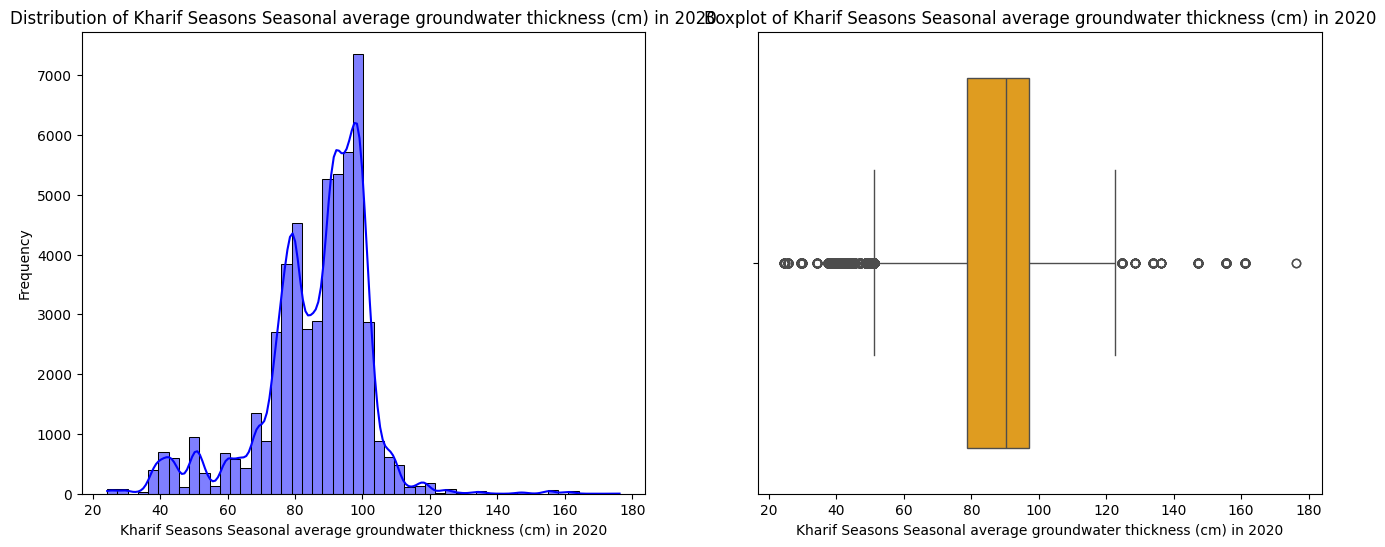


Analyzing 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020':
  Skewness: -1.006
  Kurtosis: 1.314
  Recommended Scaler: MinMaxScaler (Moderate left skew, low kurtosis)


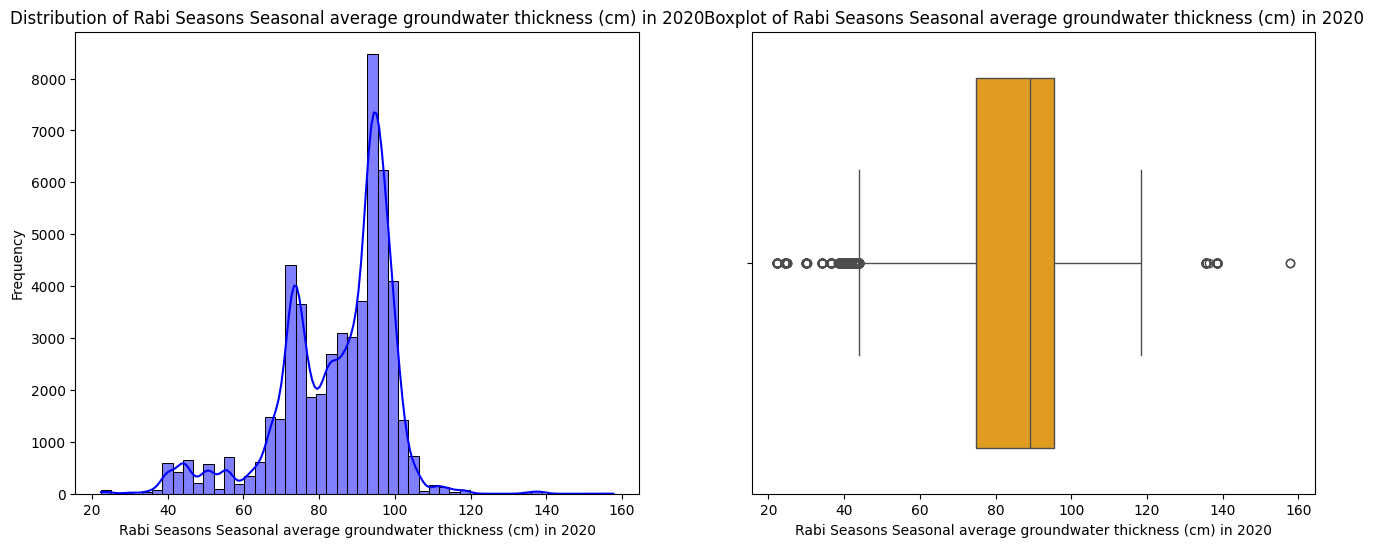


Analyzing 'Village score based on socio-economic parameters (0 to 100)':
  Skewness: 0.093
  Kurtosis: 4.138
  Recommended Scaler: RobustScaler (Data is approximately normal but has outliers - high kurtosis)


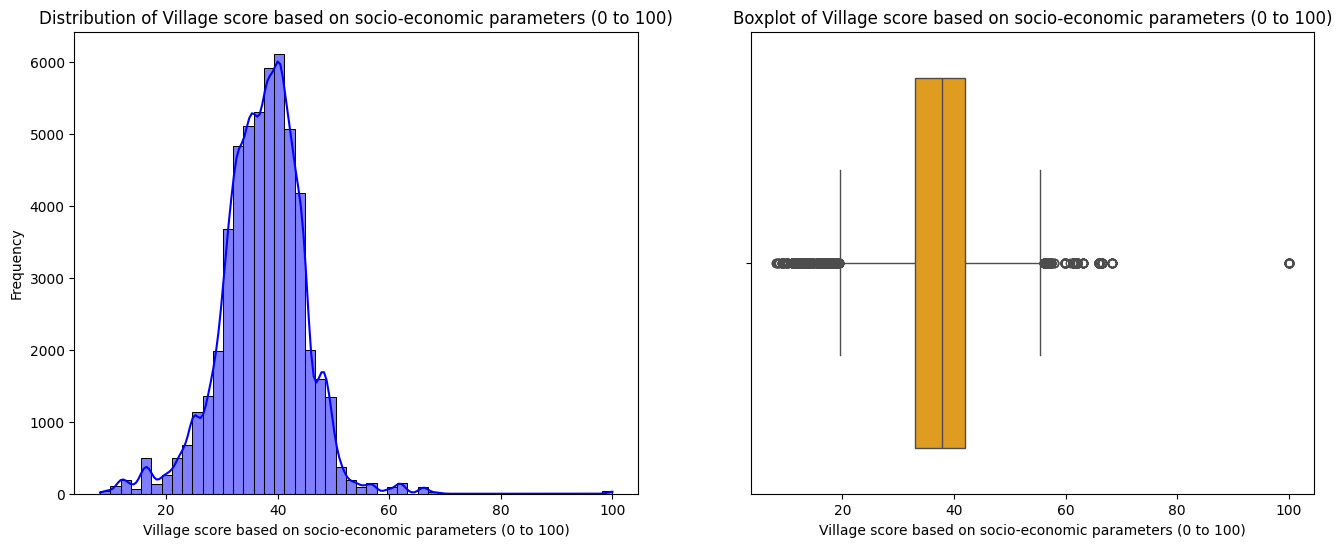


Analyzing 'Kharif Seasons Kharif Season Irrigated area in 2020':
  Skewness: -0.728
  Kurtosis: -0.809
  Recommended Scaler: MinMaxScaler (Moderate left skew, low kurtosis)


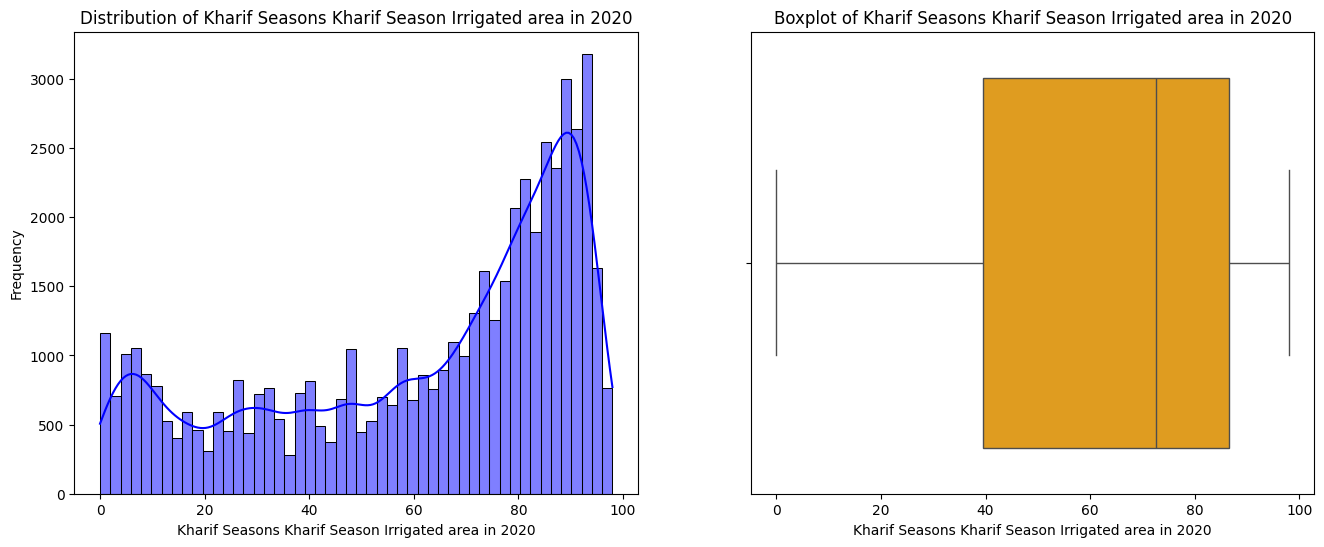


Analyzing 'Kharif Seasons Kharif Season Irrigated area in 2021':
  Skewness: -0.450
  Kurtosis: -1.094
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


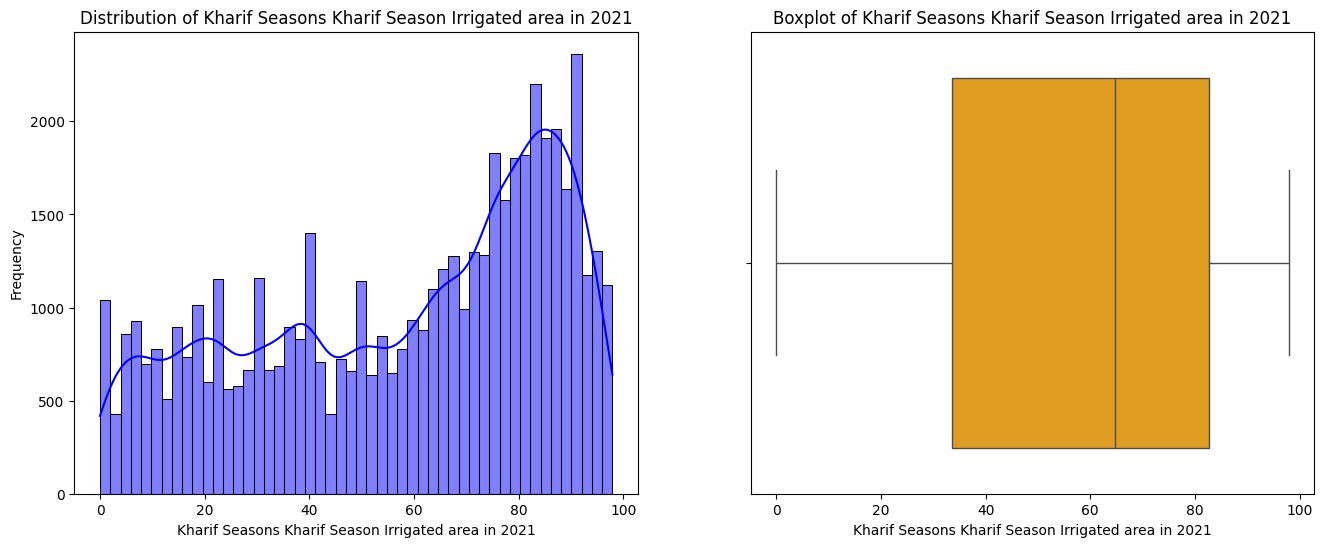


Analyzing 'Kharif Seasons Irrigated area in 2022':
  Skewness: 0.009
  Kurtosis: -0.056
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


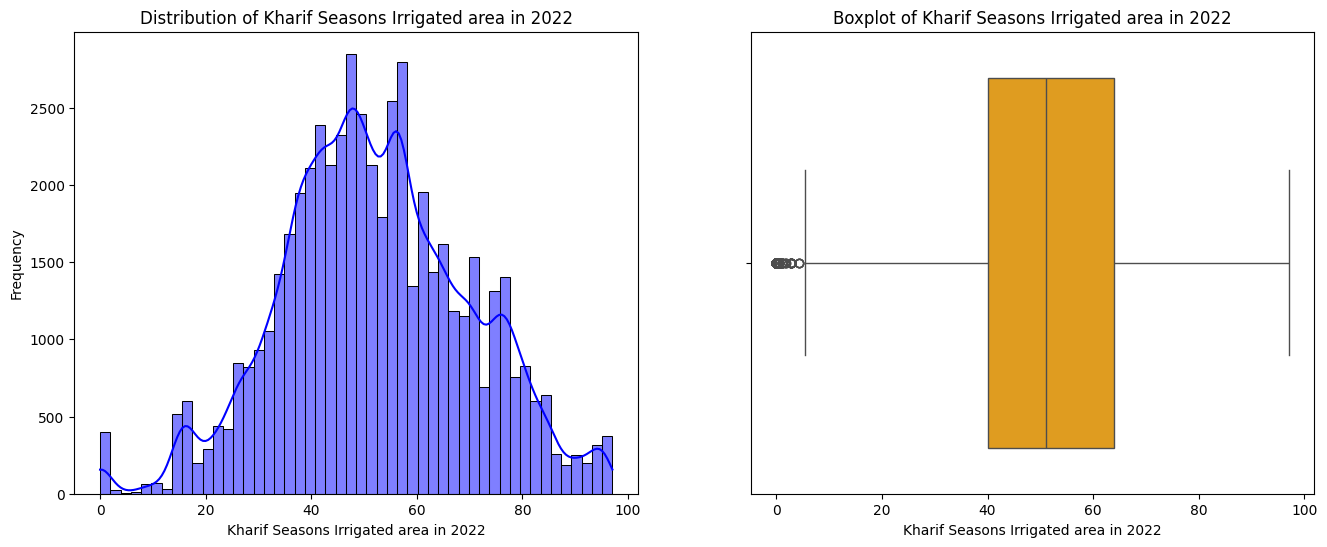


Analyzing 'Rabi Seasons Kharif Season Irrigated area in 2021':
  Skewness: -0.966
  Kurtosis: -0.239
  Recommended Scaler: MinMaxScaler (Moderate left skew, low kurtosis)


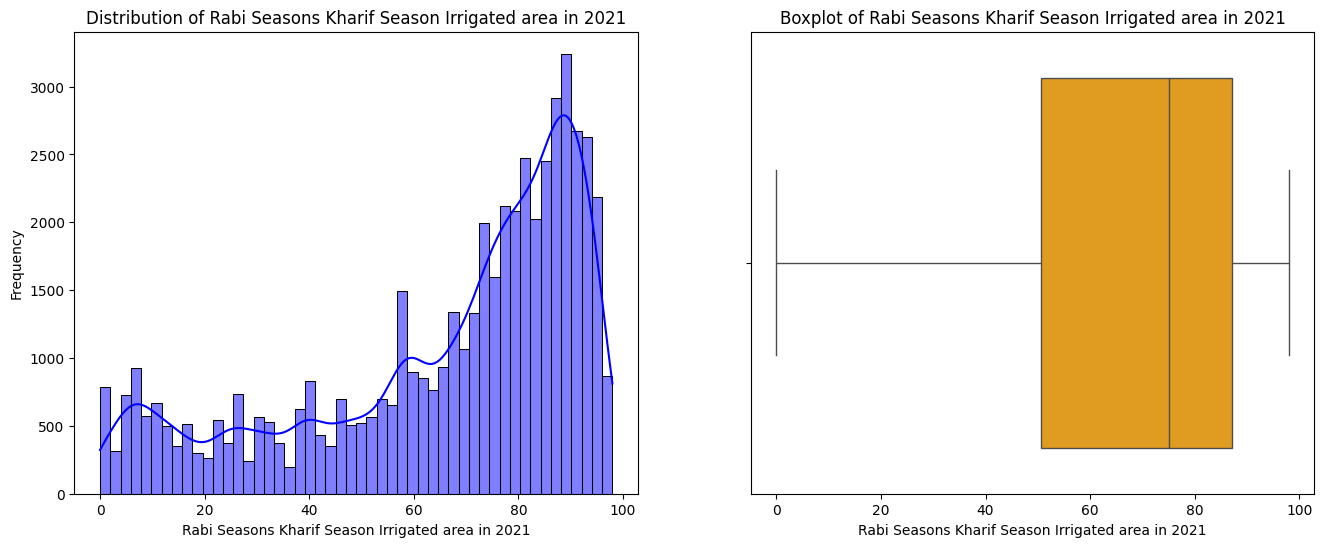


Analyzing 'Rabi Seasons Kharif Season Irrigated area in 2020':
  Skewness: -0.963
  Kurtosis: -0.431
  Recommended Scaler: MinMaxScaler (Moderate left skew, low kurtosis)


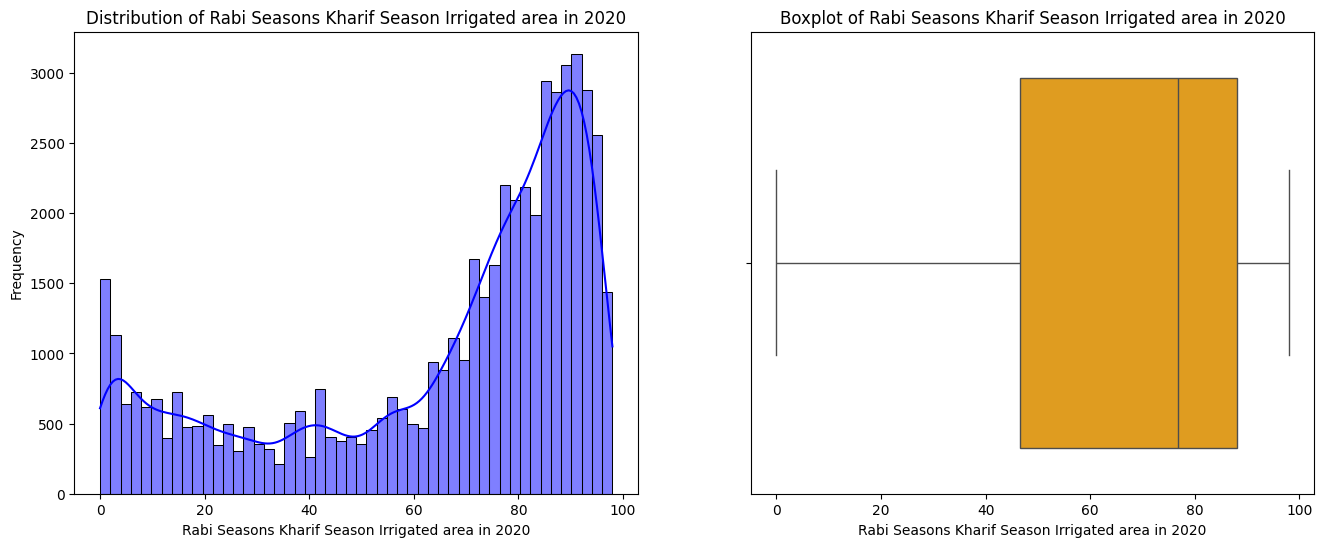


Analyzing 'Rabi Seasons Agricultural performance in 2020':
  Skewness: 0.262
  Kurtosis: -0.527
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


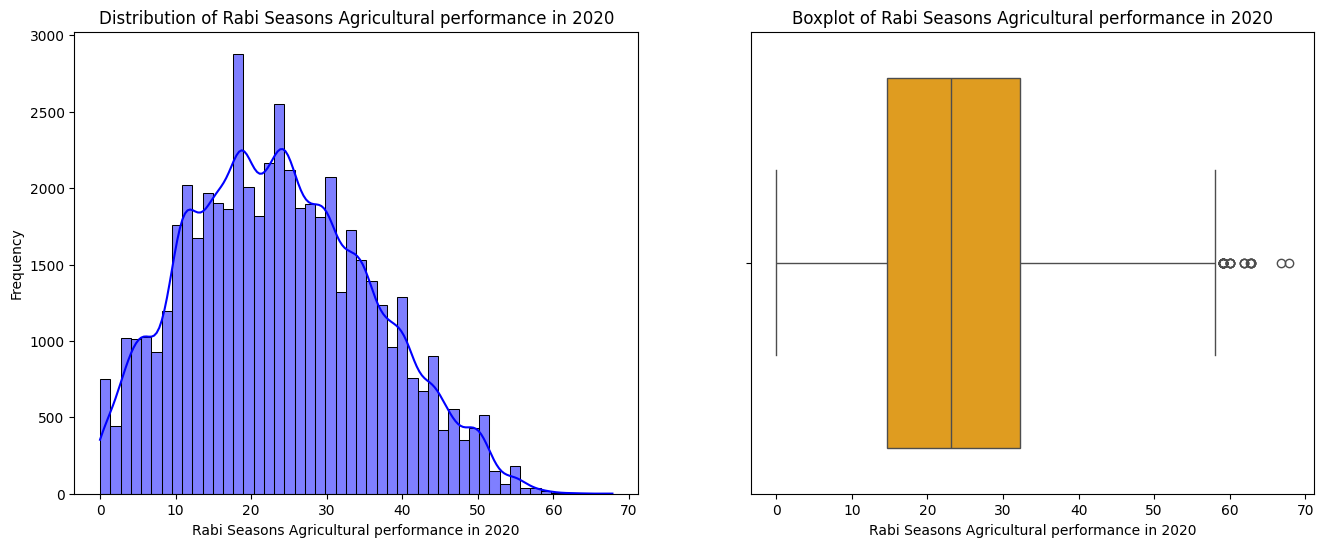


Analyzing 'Rabi Seasons Agricultural performance in 2021':
  Skewness: 0.491
  Kurtosis: 0.178
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


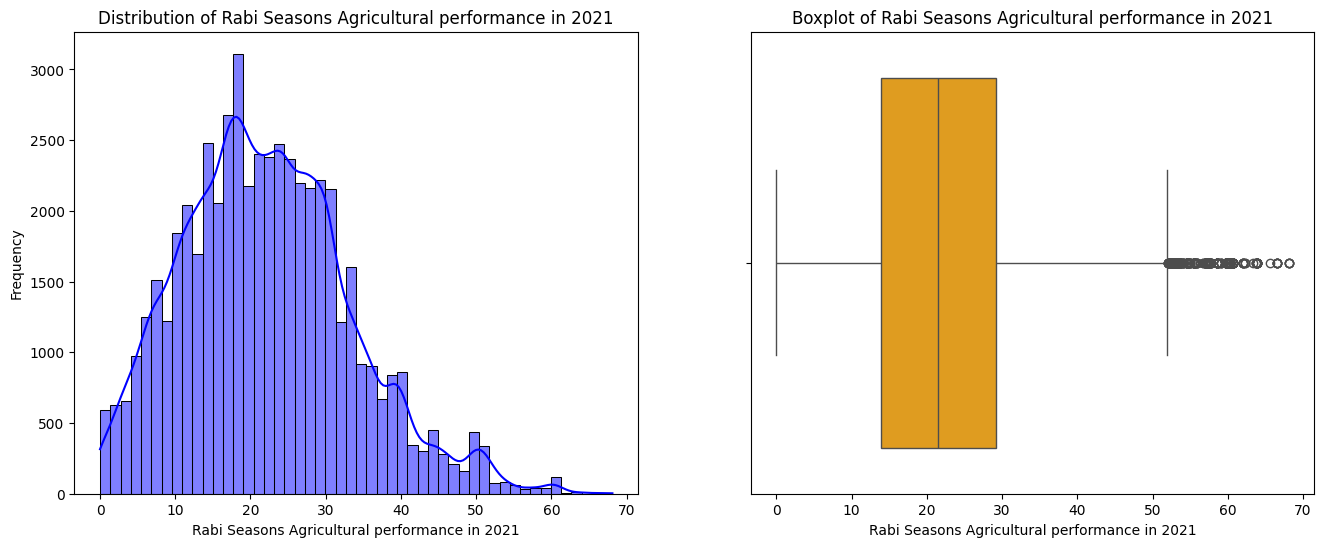


Analyzing 'Rabi Seasons Agricultural performance in 2022':
  Skewness: 0.181
  Kurtosis: -0.688
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


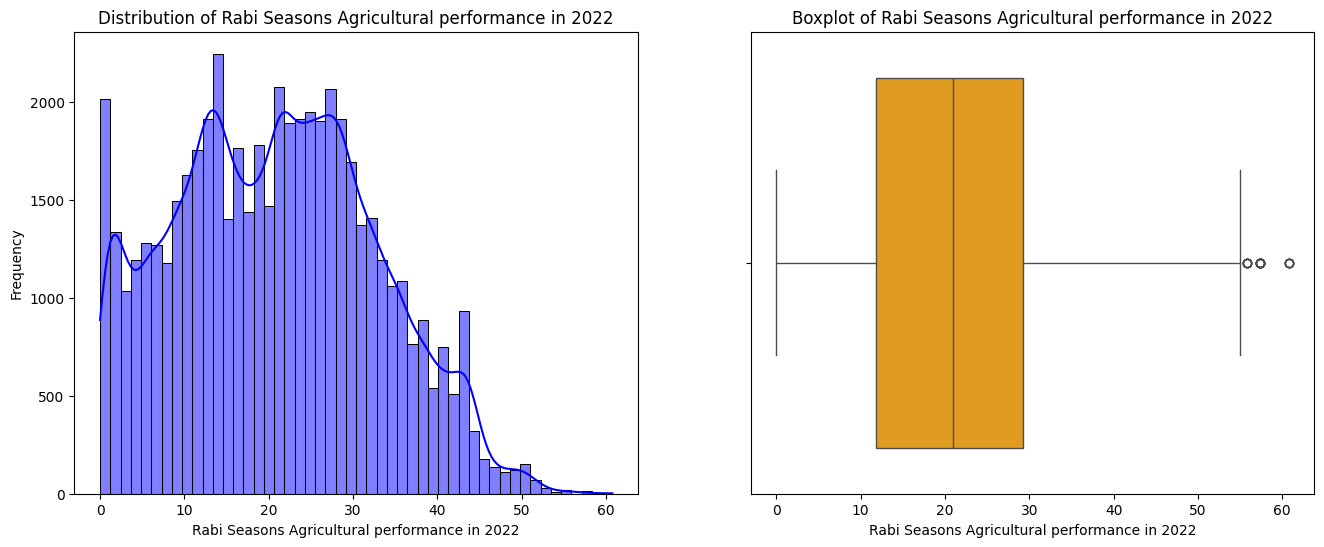


Analyzing 'Kharif Seasons Agricultural performance in 2021':
  Skewness: 0.802
  Kurtosis: -0.140
  Recommended Scaler: Log Transform (Moderate right skew, low kurtosis)


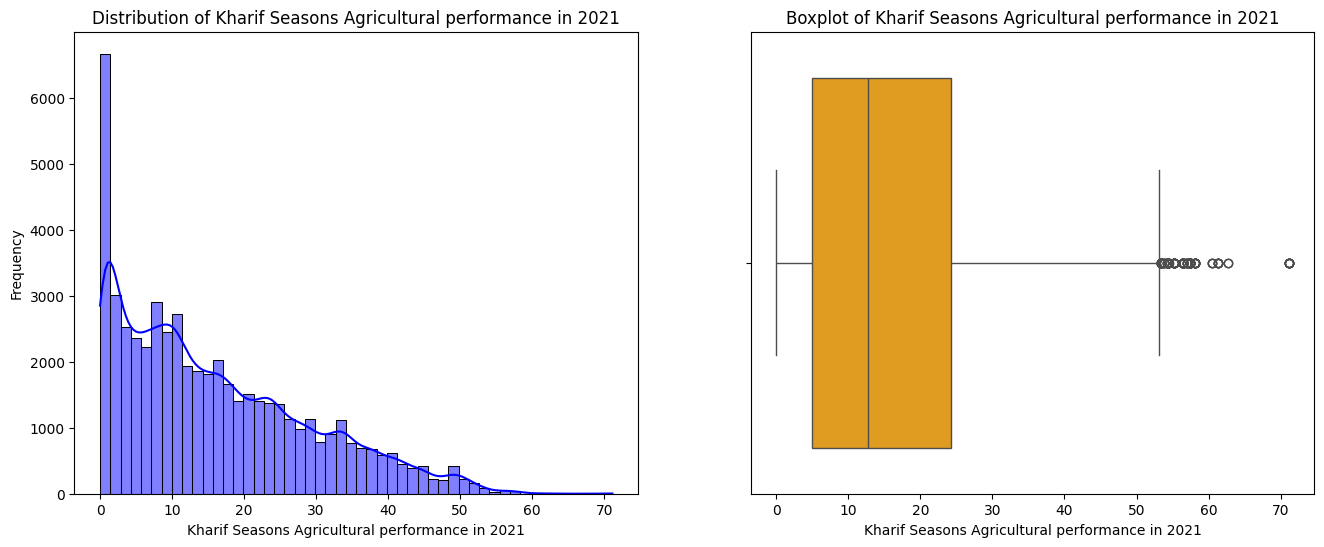


Analyzing 'Kharif Seasons Agricultural performance in 2020':
  Skewness: 0.589
  Kurtosis: -0.493
  Recommended Scaler: Log Transform (Moderate right skew, low kurtosis)


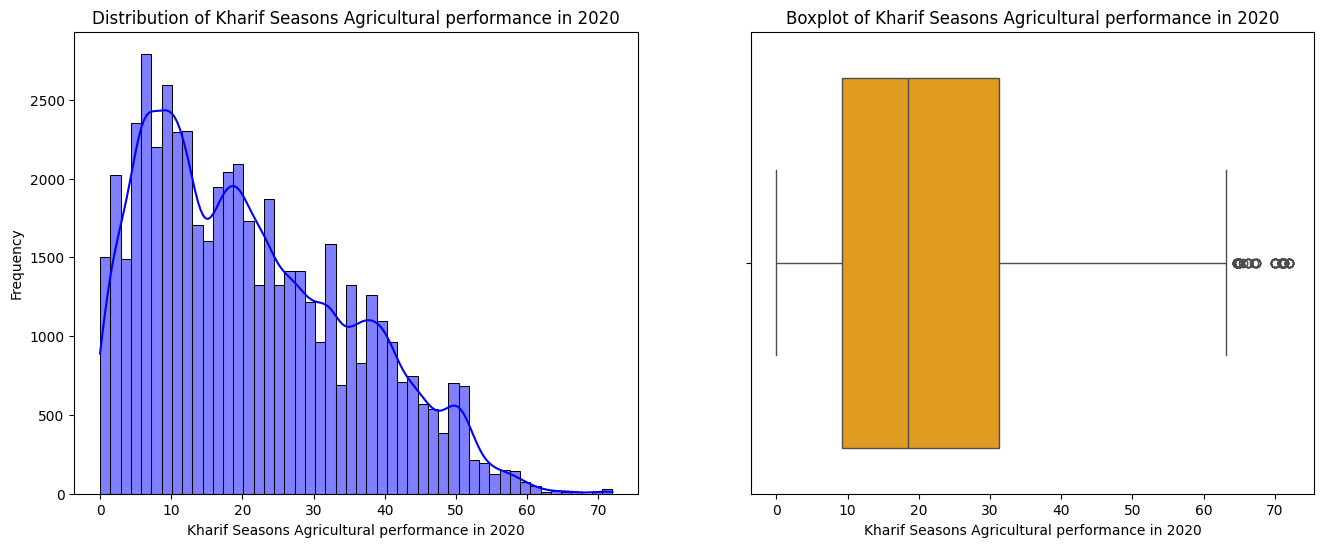


Analyzing 'Kharif Seasons Agricultural performance in 2022':
  Skewness: 0.245
  Kurtosis: -0.697
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


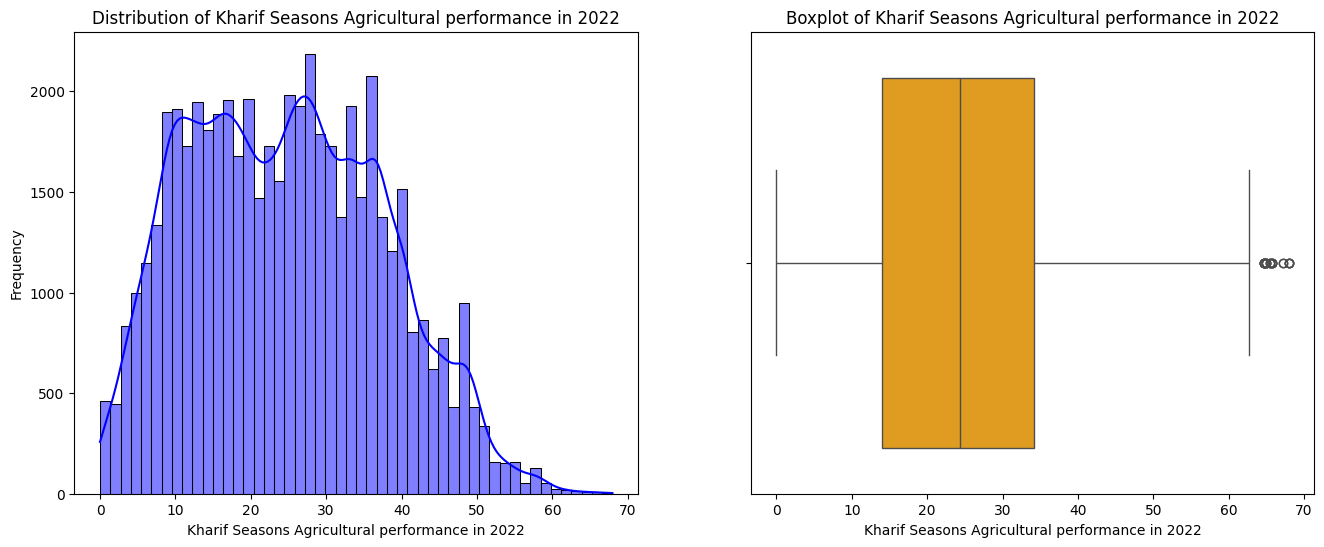


Analyzing 'Rabi Seasons Agricultural Score in 2020':
  Skewness: -0.341
  Kurtosis: -0.214
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


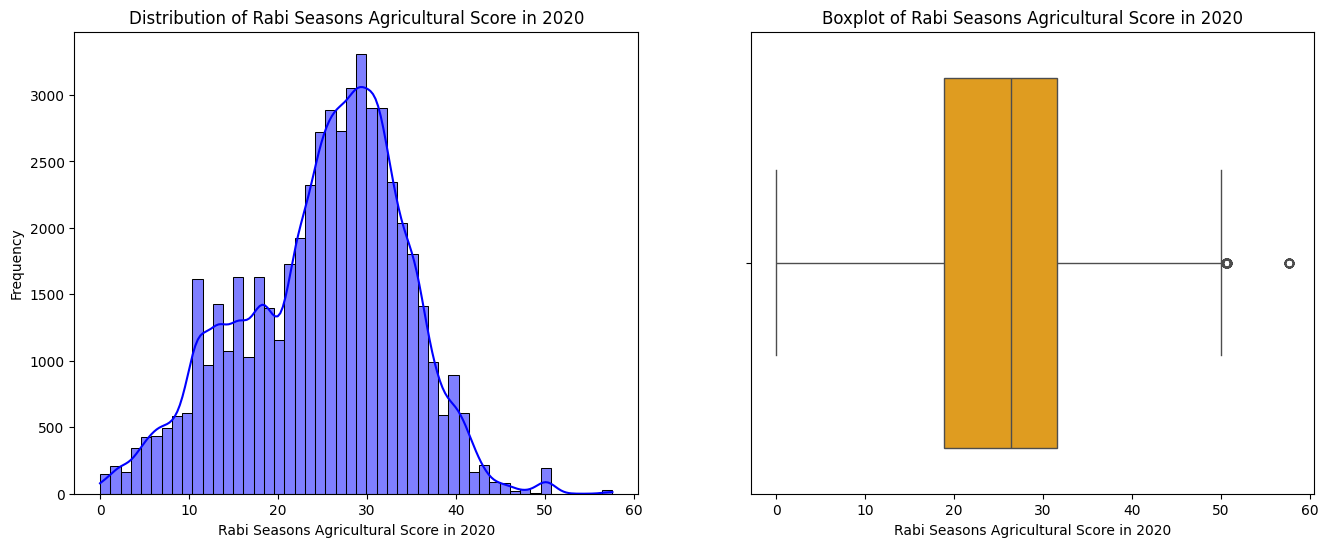


Analyzing 'Rabi Seasons Agricultural Score in 2021':
  Skewness: -0.323
  Kurtosis: 0.001
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


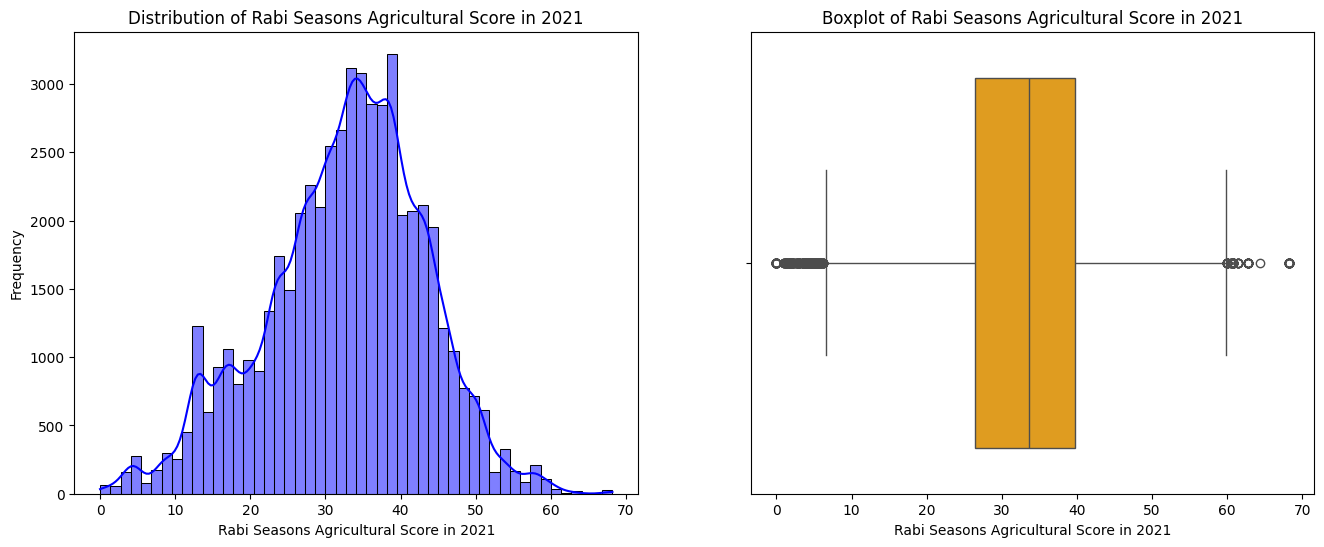


Analyzing 'Rabi Seasons Agricultural Score in 2022':
  Skewness: -0.015
  Kurtosis: -0.482
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


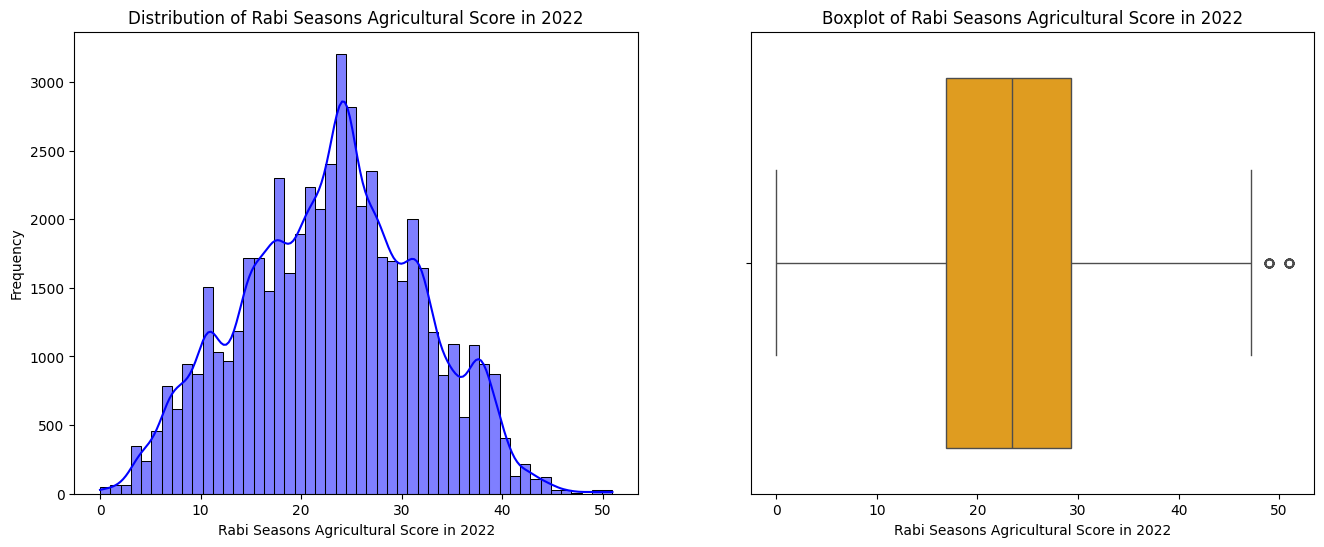


Analyzing 'Kharif Seasons Agricultural Score in 2020':
  Skewness: -0.061
  Kurtosis: -0.436
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


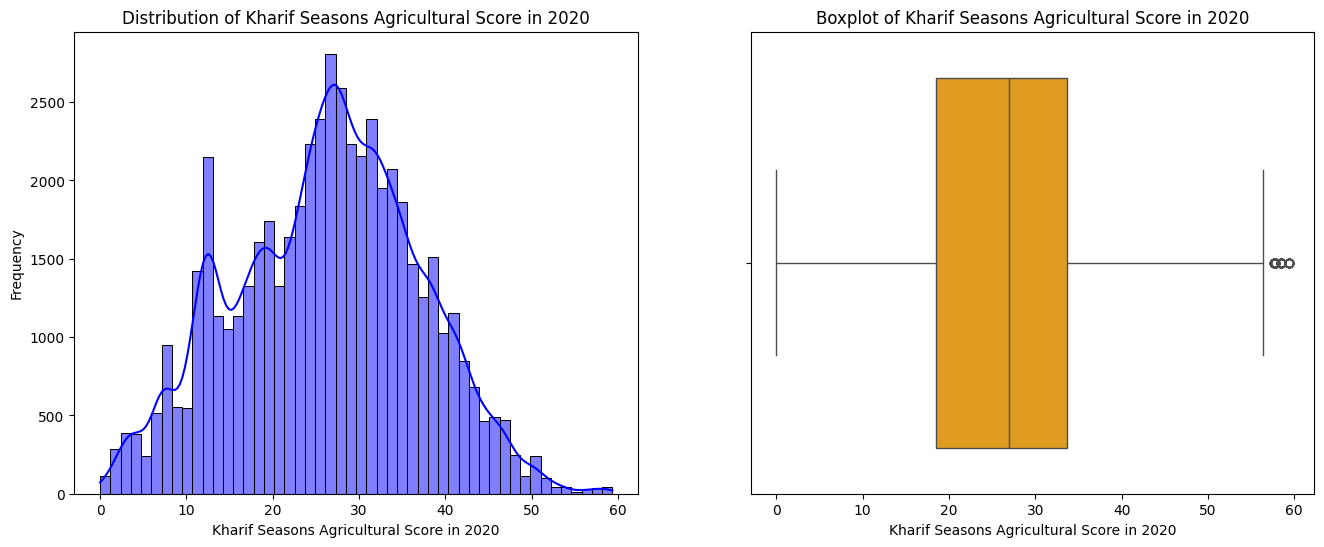


Analyzing 'Kharif Seasons Agricultural Score in 2021':
  Skewness: 0.281
  Kurtosis: -0.056
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


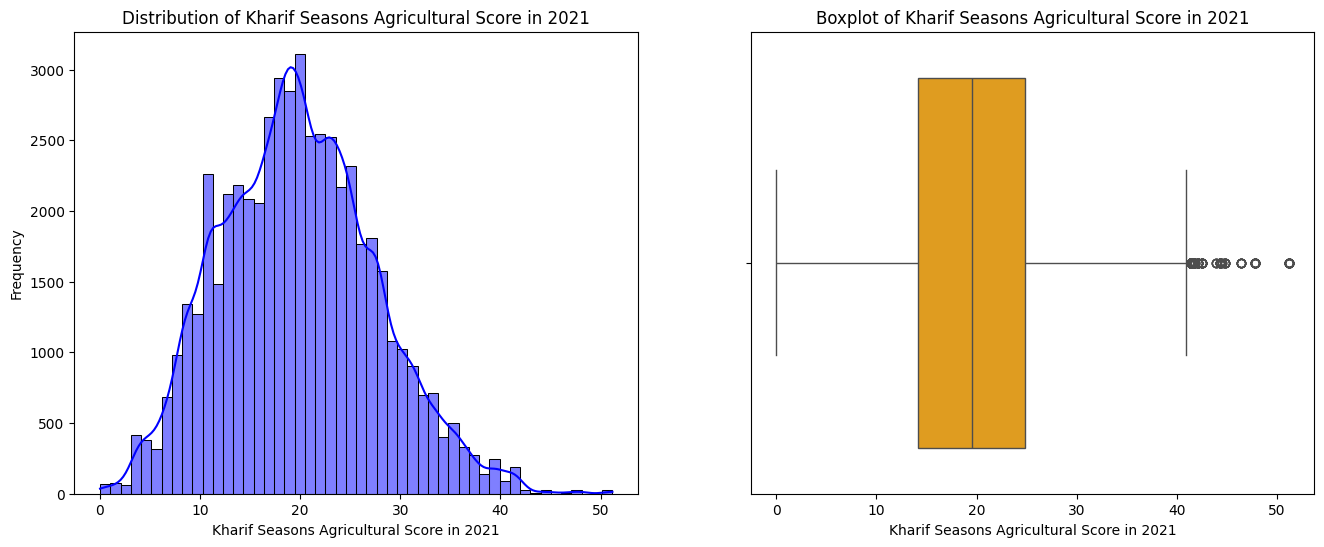


Analyzing 'Kharif Seasons Agricultural Score in 2022':
  Skewness: 0.021
  Kurtosis: -0.134
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


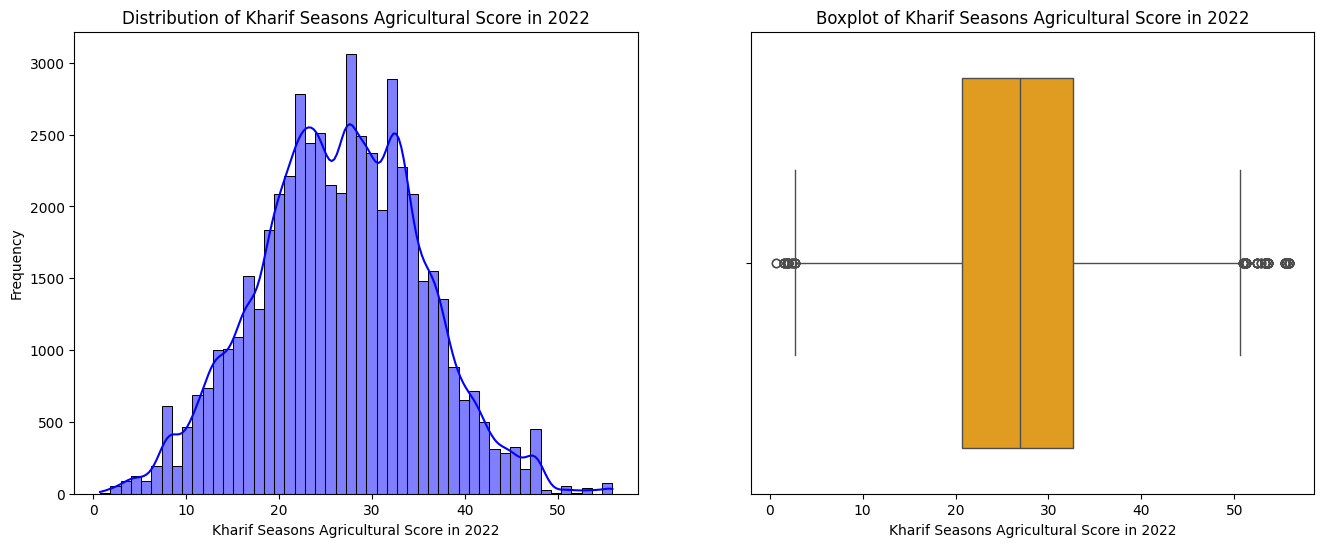


Analyzing 'Rabi Seasons Cropping density in 2020':
  Skewness: -0.003
  Kurtosis: -0.977
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


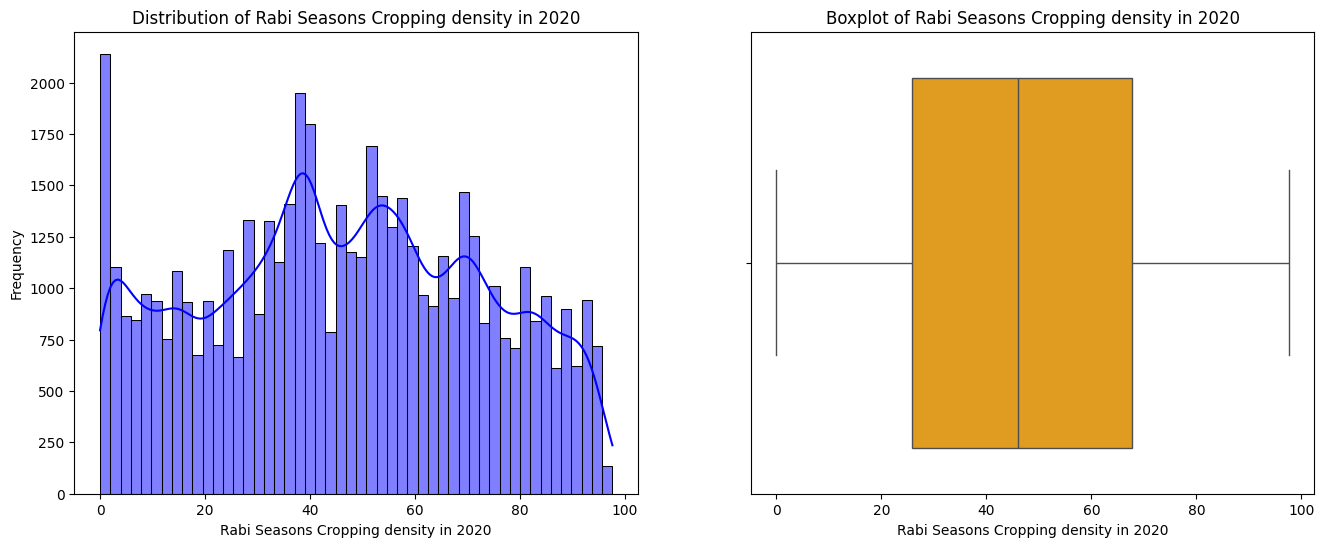


Analyzing 'Rabi Seasons Cropping density in 2021':
  Skewness: -0.019
  Kurtosis: -0.973
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


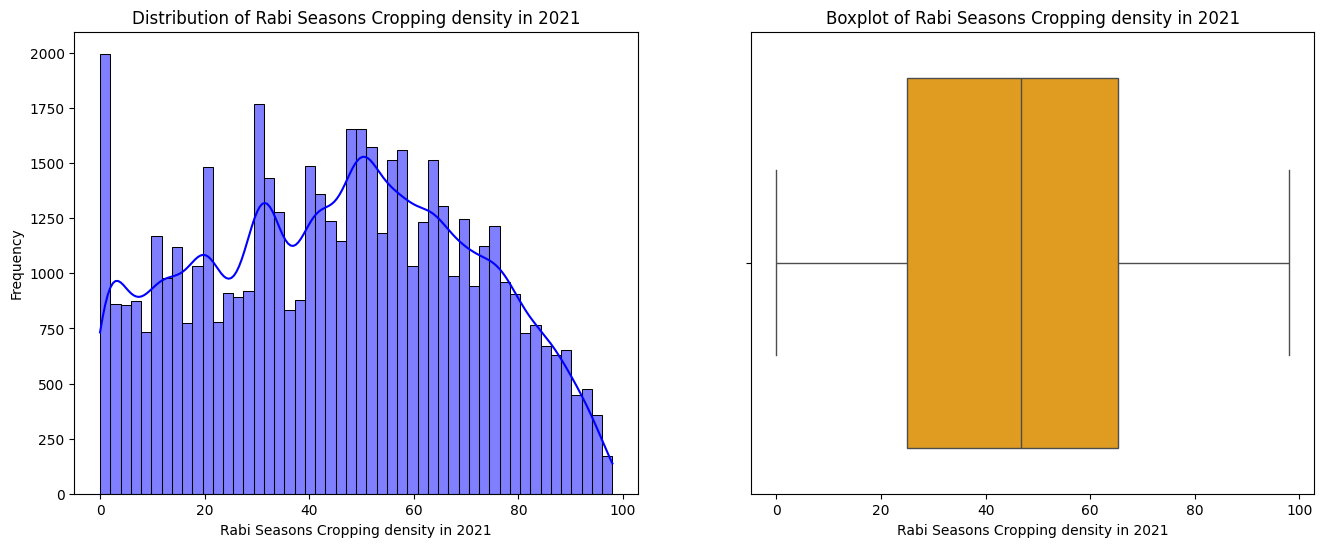


Analyzing 'Rabi Seasons Cropping density in 2022':
  Skewness: -0.046
  Kurtosis: -1.032
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


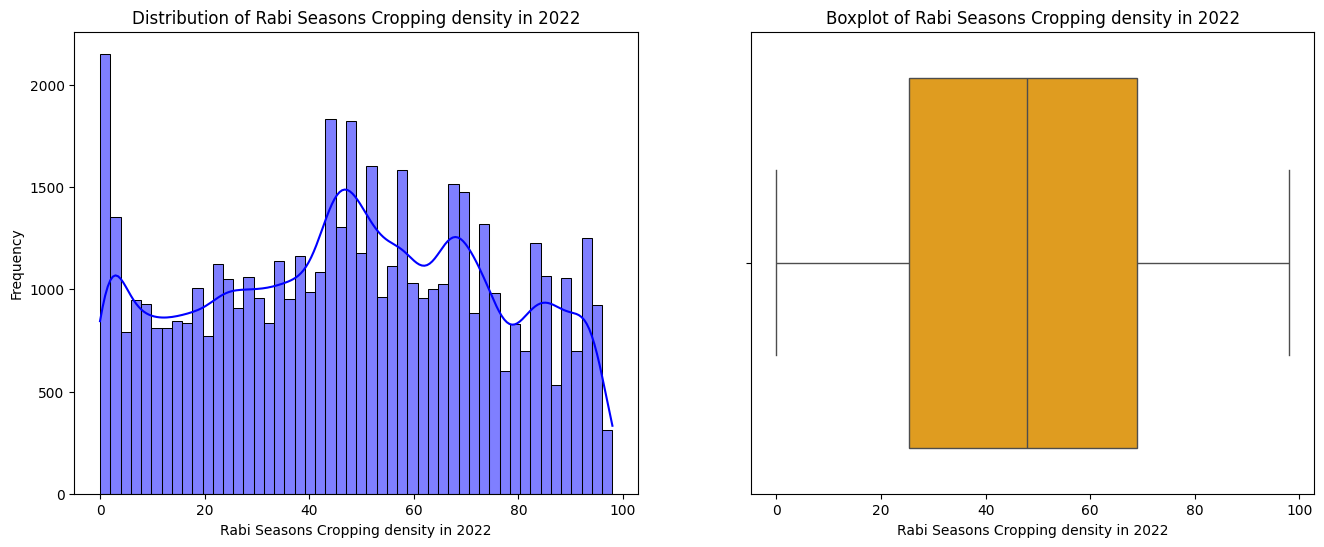


Analyzing 'Kharif Seasons Cropping density in 2020':
  Skewness: 0.091
  Kurtosis: -0.943
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


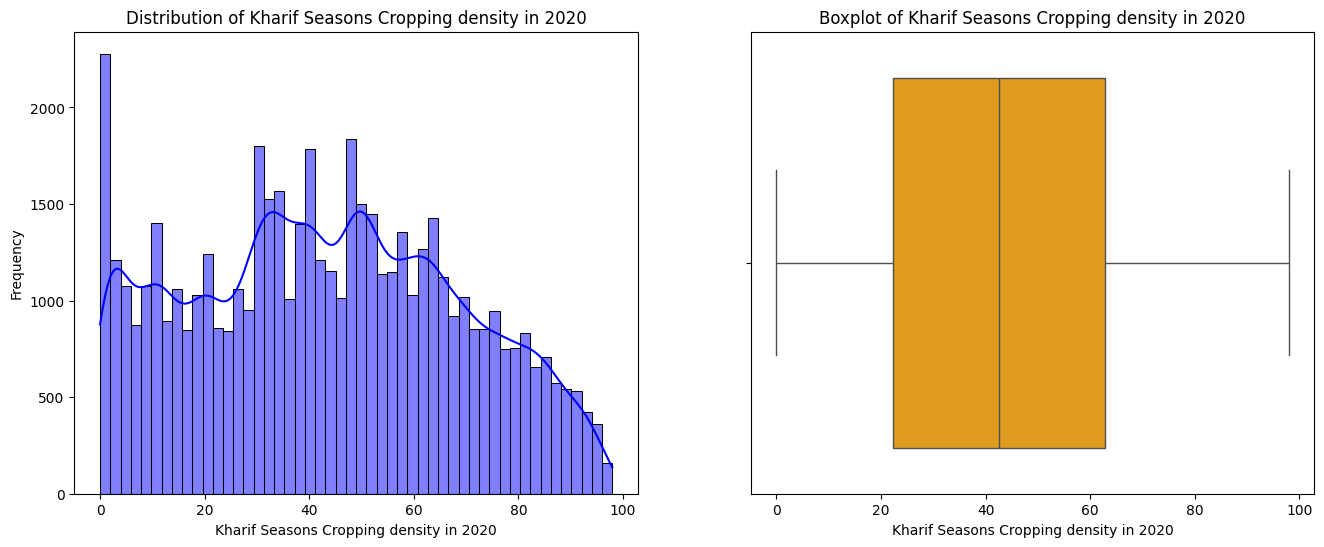


Analyzing 'Kharif Seasons Cropping density in 2022':
  Skewness: -0.394
  Kurtosis: -0.018
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


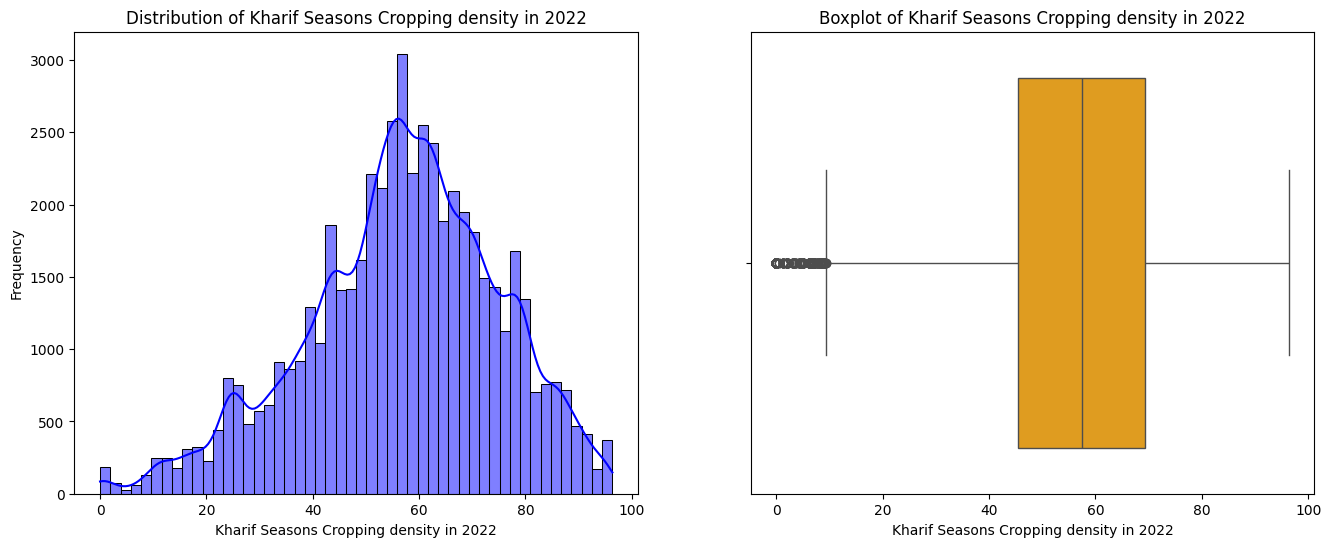


Analyzing 'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020':
  Skewness: -0.130
  Kurtosis: 0.984
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


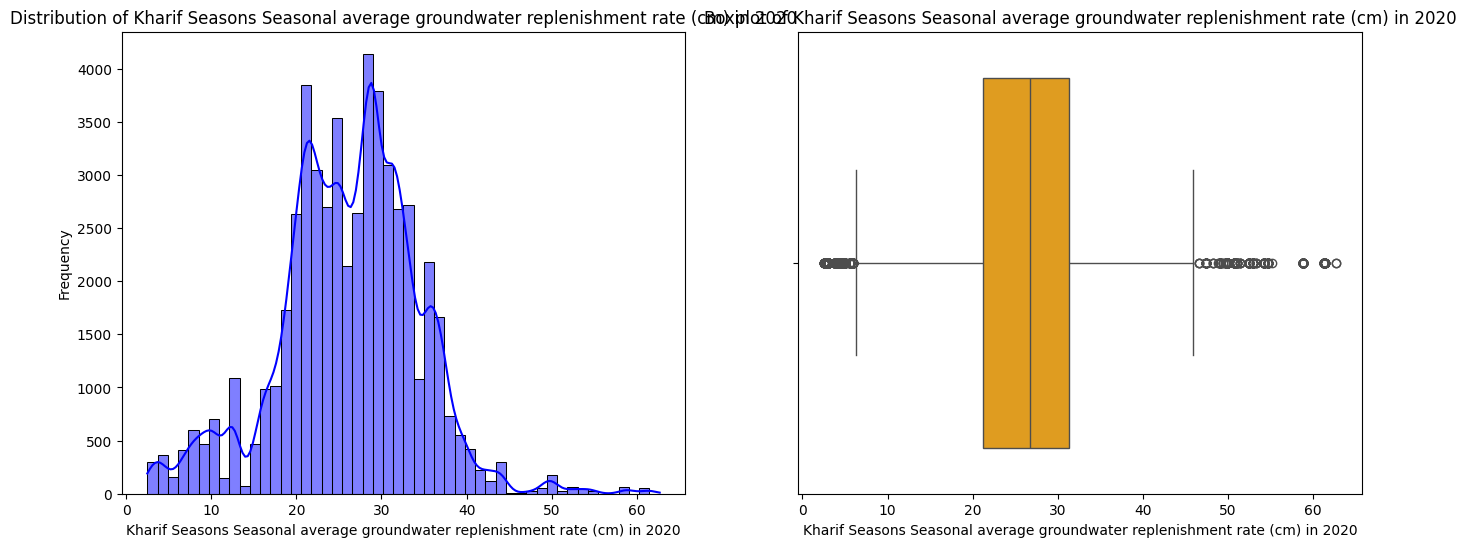


Analyzing 'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021':
  Skewness: -0.049
  Kurtosis: 0.248
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


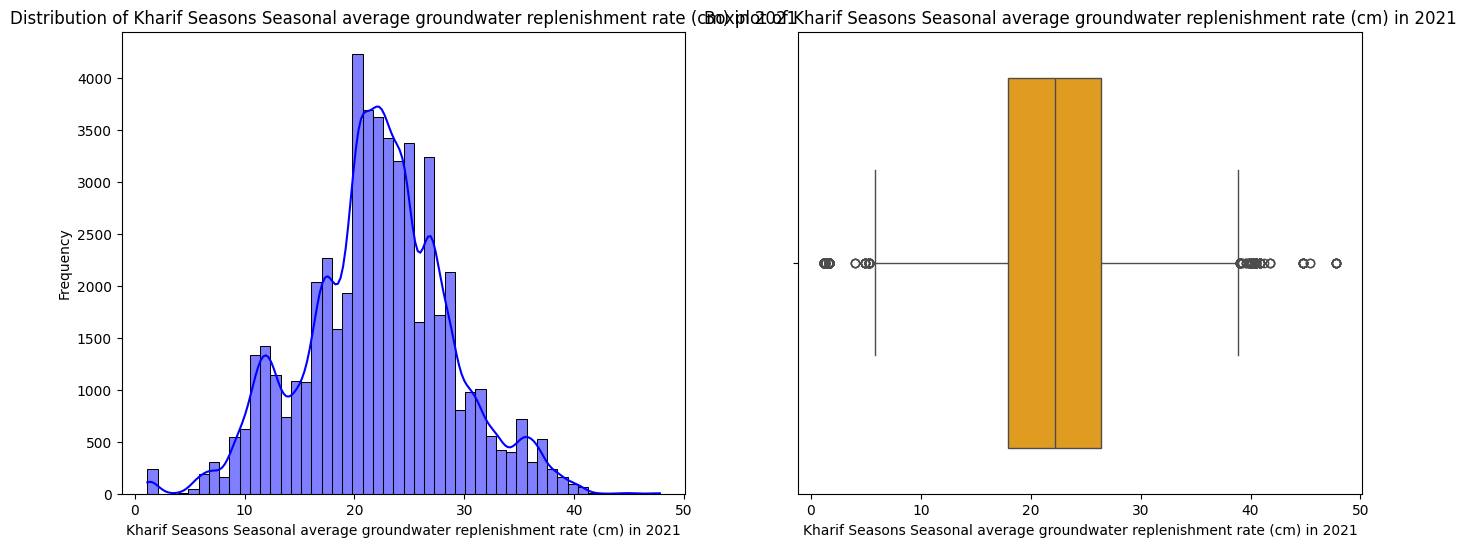


Analyzing 'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2022':
  Skewness: 0.093
  Kurtosis: 0.347
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


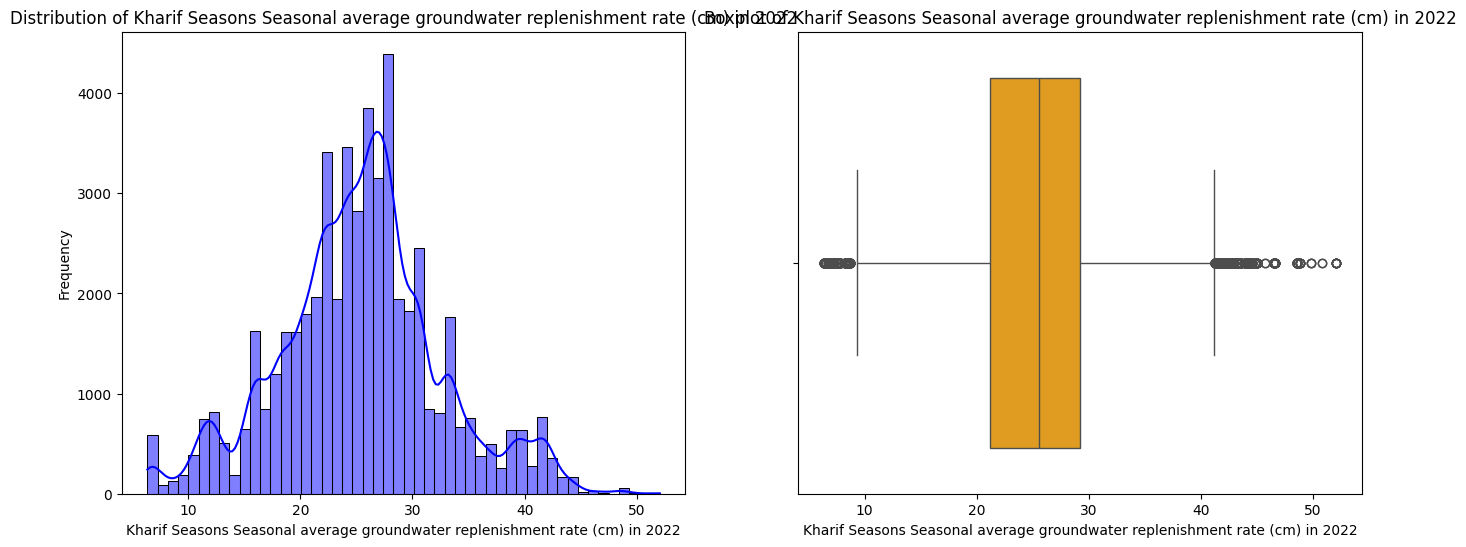


Analyzing 'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020':
  Skewness: 0.299
  Kurtosis: 1.977
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


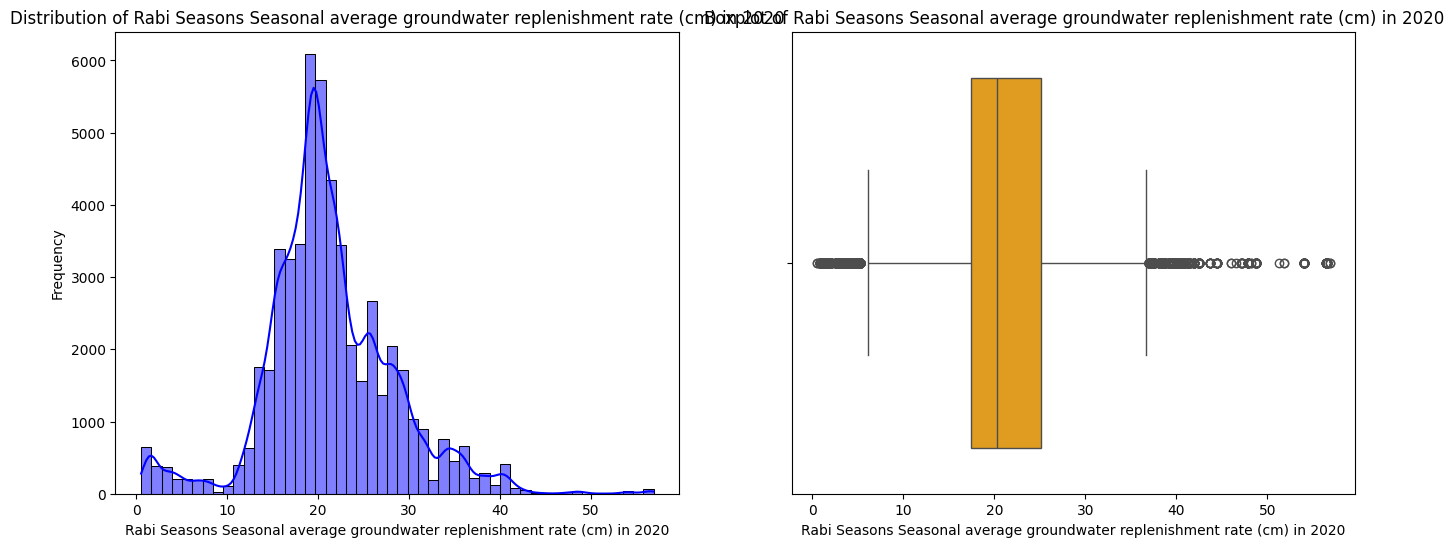


Analyzing 'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021':
  Skewness: -0.111
  Kurtosis: 0.656
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


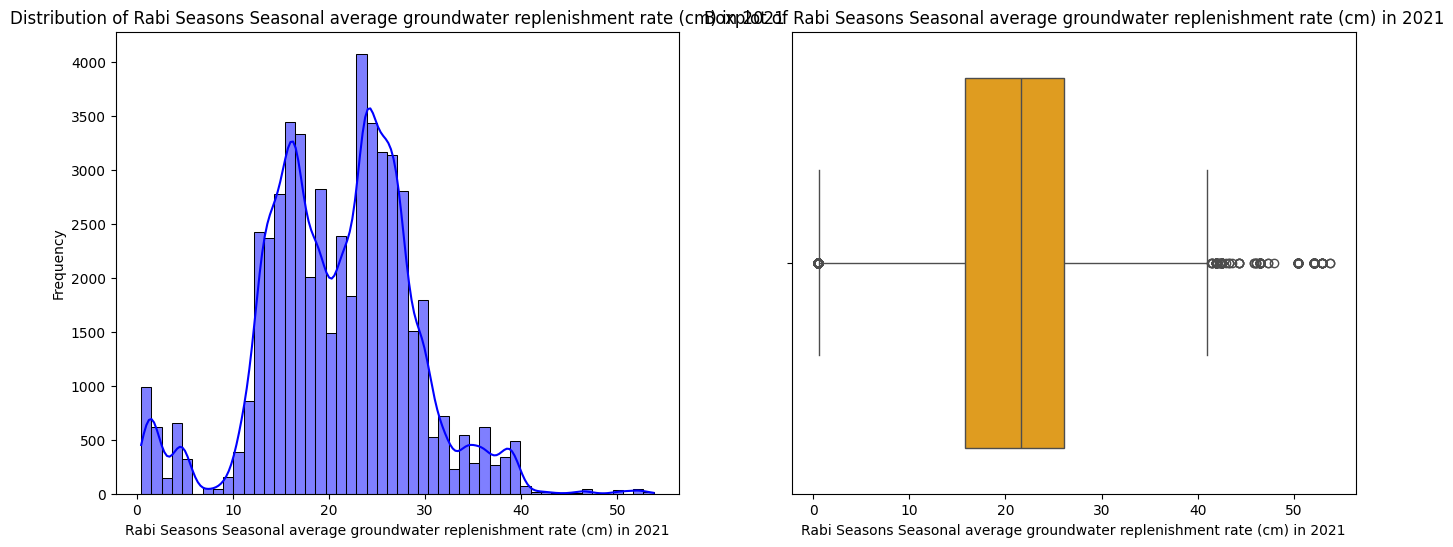


Analyzing 'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022':
  Skewness: 1.254
  Kurtosis: 2.606
  Recommended Scaler: Log Transform (Moderate right skew, low kurtosis)


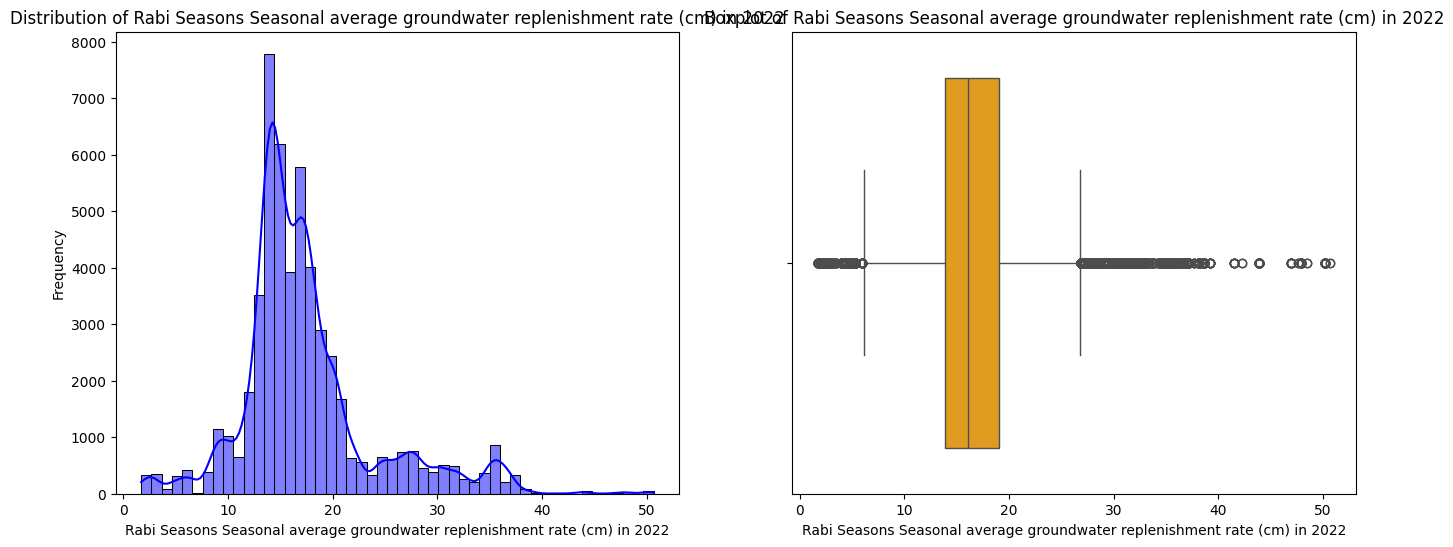


Analyzing 'K021-Seasonal Average Rainfall (mm)':
  Skewness: 0.247
  Kurtosis: 0.205
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


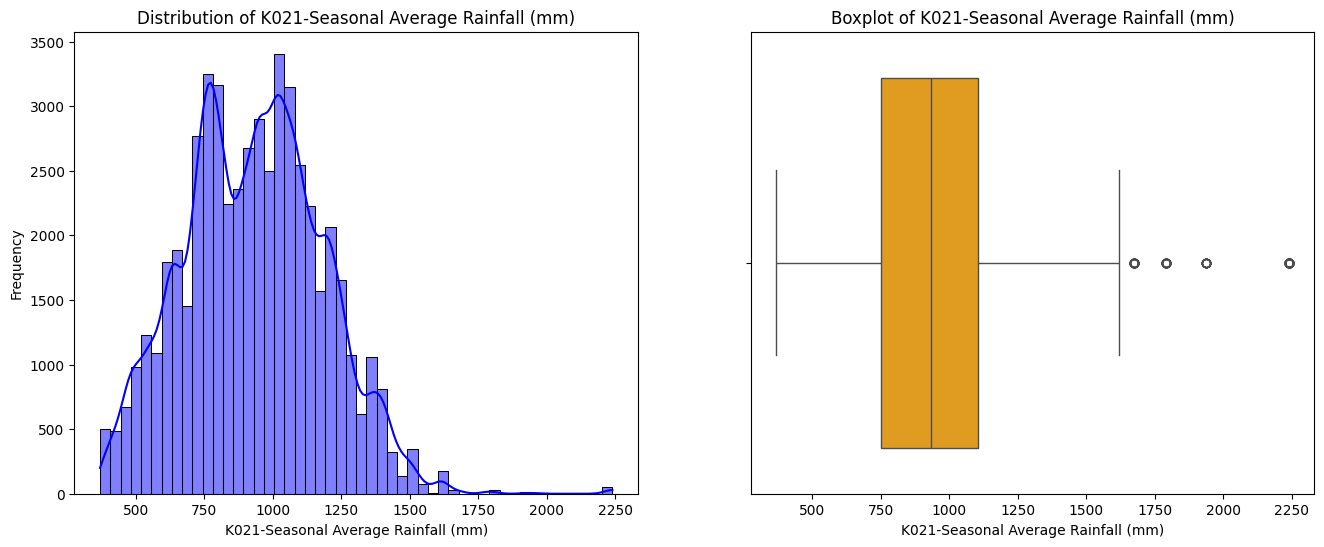


Analyzing 'K022-Seasonal Average Rainfall (mm)':
  Skewness: 0.347
  Kurtosis: -0.616
  Recommended Scaler: StandardScaler (Data is approximately normal, low kurtosis)


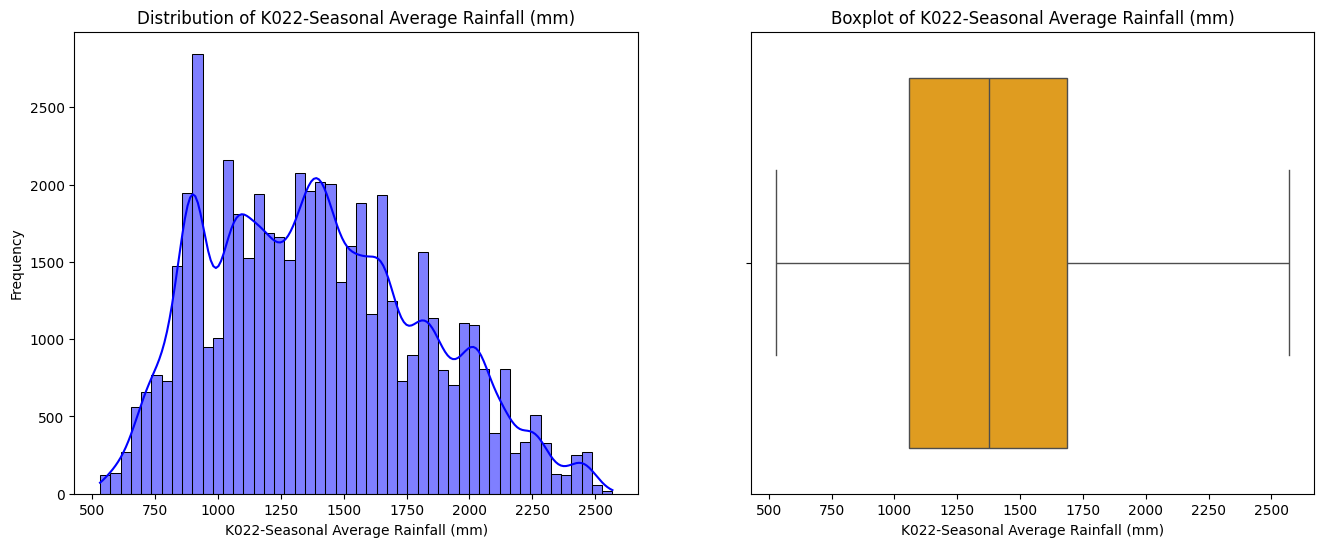


Analyzing 'R021-Seasonal Average Rainfall (mm)':
  Skewness: 1.262
  Kurtosis: 2.029
  Recommended Scaler: Log Transform (Moderate right skew, low kurtosis)


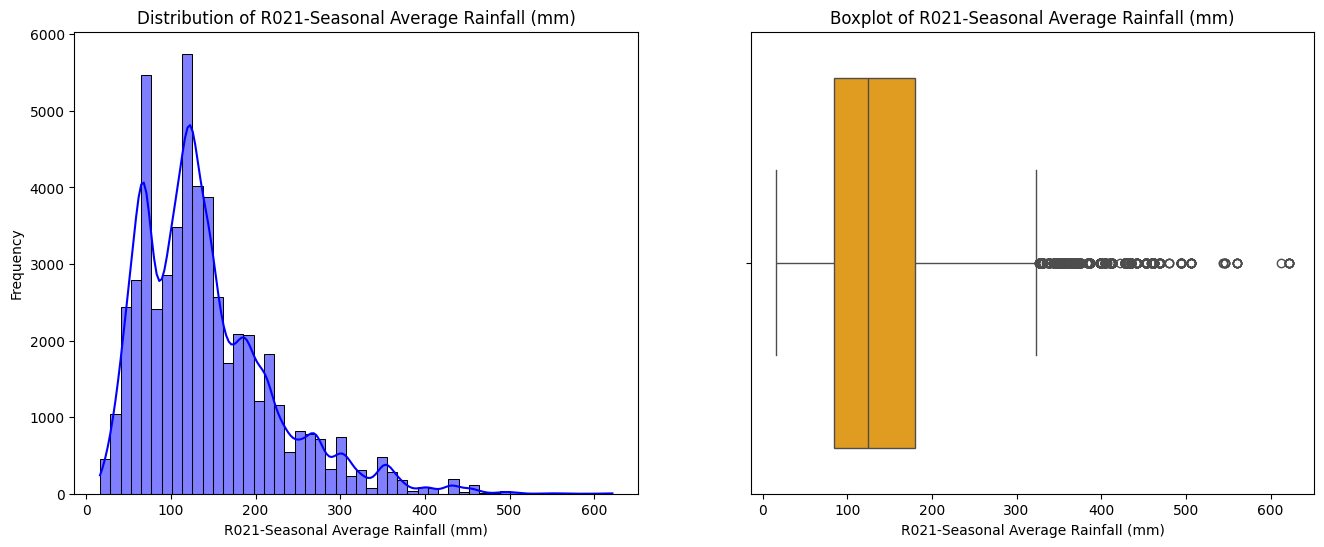


Analyzing 'R020-Seasonal Average Rainfall (mm)':
  Skewness: 1.917
  Kurtosis: 4.806
  Recommended Scaler: Yeo-Johnson (Moderate right skew, high kurtosis)


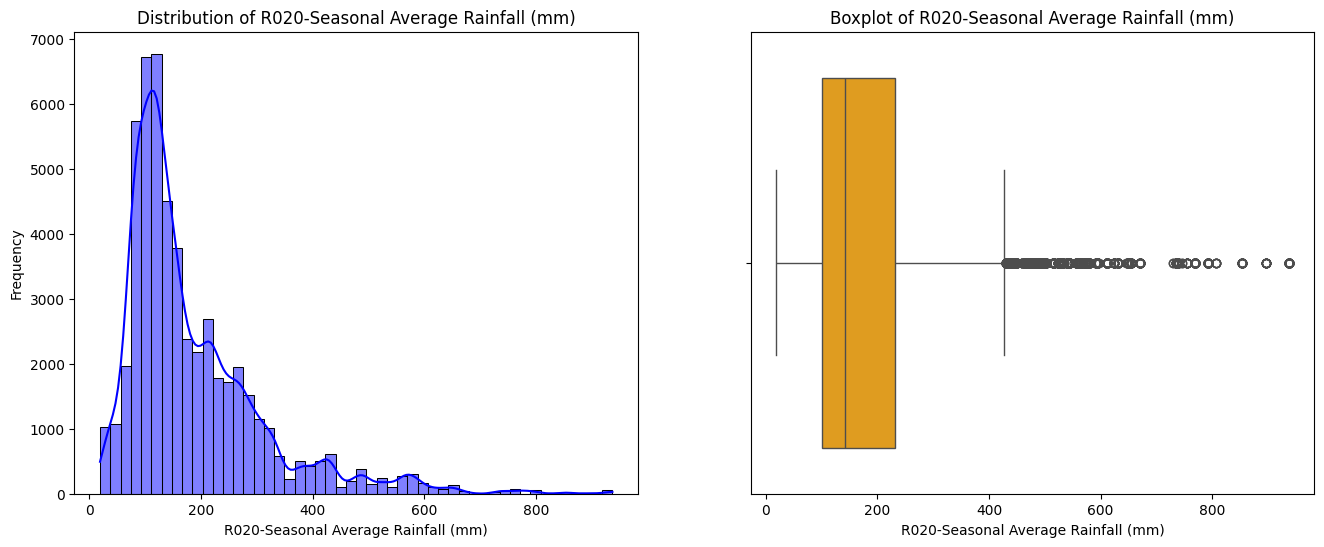


Analyzing 'R022-Seasonal Average Rainfall (mm)':
  Skewness: 1.631
  Kurtosis: 2.462
  Recommended Scaler: Log Transform (Moderate right skew, low kurtosis)


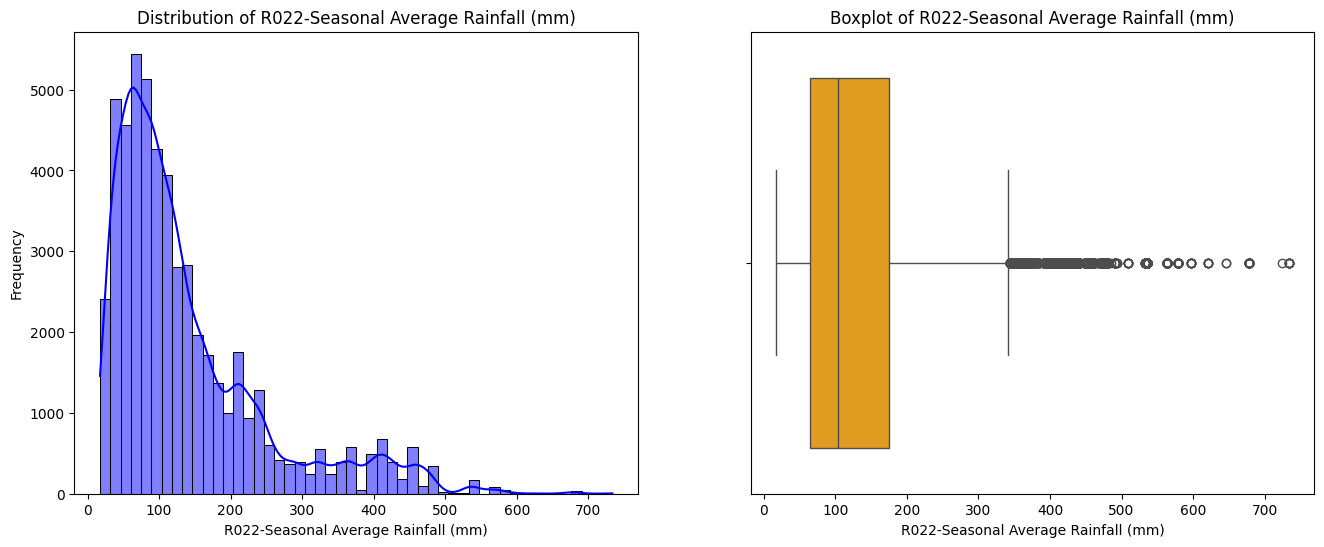

In [65]:
recommendations_num = analyze_distributions(df_train,cols_num_transform)

In [66]:
df_train = apply_transformations(df_train, recommendations_num)

In [67]:
df_test = apply_transformations(df_test, recommendations_num)

In [68]:
### Apply log transoformation for Non_Agriculture_Income
df_train= log_transform(df_train,["Non_Agriculture_Income"])

In [69]:
df_test= log_transform(df_test,["Non_Agriculture_Income"])


### Drop Columns

In [70]:
cols_to_drop

['FarmerID',
 'DISTRICT',
 'CITY',
 'VILLAGE',
 'Zipcode',
 'Zone',
 'Sub-zone',
 'Sorting District',
 'Location',
 'Avg_Disbursement_Amount_Bureau',
 'Address type',
 'Ownership',
 'Rabi Seasons Type of soil in 2021',
 'Rabi Seasons Type of soil in 2022',
 'Kharif Seasons Type of soil in 2021',
 'Kharif Seasons Type of soil in 2022',
 'Rabi Seasons Type of water bodies in hectares 2021',
 'Rabi Seasons Type of water bodies in hectares 2022',
 'Kharif Seasons Type of water bodies in hectares 2022',
 'K022-Village category based on socio-economic parameters (Good, Average, Poor)',
 'Rabi Seasons Agro Ecological Sub Zone in 2021',
 'Rabi Seasons Agro Ecological Sub Zone in 2022',
 'Kharif Seasons Agro Ecological Sub Zone in 2022',
 'Rabi Seasons Type of soil in 2020',
 'Kharif Seasons Type of soil in 2020',
 'Rabi Seasons Type of water bodies in hectares 2020',
 'Kharif Seasons Type of water bodies in hectares 2020',
 'Kharif Seasons Type of water bodies in hectares 2021',
 'Rabi Seasons

In [71]:
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)


In [72]:
len(list(df_train.columns))

114

In [73]:
len(list(df_test.columns))

113

In [119]:
df_train

,SEX,MARITAL_STATUS,No_of_Active_Loan_In_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,K022-Proximity to nearest mandi (Km),K022-Proximity to nearest railway (Km),K022-Seasonal Average Rainfall (mm),R022-Seasonal Average Rainfall (mm),K021-Seasonal Average Rainfall (mm),...,State_TELANGANA,State_UTTAR PRADESH,State_WEST BENGAL,REGION_EAST,REGION_NORTH,REGION_SOUTH,"Village category based on socio-economic parameters (Good, Average, Poor)_GOOD","Village category based on socio-economic parameters (Good, Average, Poor)_POOR","K022-Village category based on Agri parameters (Good, Average, Poor)_POOR","R022-Village category based on Agri parameters (Good, Average, Poor)_POOR"
0,1,1,0,11.512935,10.00,14.7,11.5,0.563747,4.409885,0.085999,...,0,0,0,0,0,0,0,1,1,1
1,1,1,0,10.596660,12.00,3.5,1.3,0.447195,4.891101,0.559917,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,13.122365,6.00,11.2,0.0,-0.513409,3.757472,-0.153726,...,0,0,0,1,0,0,0,1,1,1
3,1,1,14,13.107252,5.00,20.5,19.0,0.328400,5.356869,0.845840,...,0,0,0,0,0,0,0,1,0,0
4,1,1,0,10.596660,5.25,0.0,6.7,-0.067315,3.815071,0.472500,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53301,1,1,0,0.000000,10.00,12.2,4.1,-0.726258,6.078926,-0.810974,...,0,0,0,0,0,1,0,1,1,1
53302,1,0,3,11.512935,9.00,11.9,18.0,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,1
53303,1,1,0,11.512935,6.00,2.1,10.6,-0.520987,6.127502,-0.527422,...,0,0,0,0,0,1,0,0,1,1
53304,1,1,0,0.000000,5.00,17.2,19.3,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,0


#### Drop high correlated columns

In [ ]:

# Compute correlation matrix
df_temp = df_train.copy()
corr_matrix = df_temp.corr()

# Find highly correlated features (absolute correlation > 0.9)
upper_triangle = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))  # Upper triangle matrix
high_corr_cols = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# Drop highly correlated columns
df_reduced = df_temp.drop(columns=high_corr_cols)

print("Columns to drop:", high_corr_cols)
print("Remaining columns:", df_reduced.columns)

df_train = df_train.drop(columns=high_corr_cols)
df_test = df_test.drop(columns=high_corr_cols)

In [120]:
from datetime import datetime

# Get current timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Format: YYYYMMDD_HHMMSS
df_train.to_csv(f"/home/jovyan/pearl_challenge/data/train_processed_{timestamp}.csv", index=False)
df_test.to_csv(f"/home/jovyan/pearl_challenge/data/test_processed_{timestamp}.csv", index=False)

In [121]:
df_train = pd.read_csv(f"/home/jovyan/pearl_challenge/data/train_processed_{timestamp}.csv")
df_test = pd.read_csv(f"/home/jovyan/pearl_challenge/data/test_processed_{timestamp}.csv")

In [123]:
df_train

,SEX,MARITAL_STATUS,No_of_Active_Loan_In_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,K022-Proximity to nearest mandi (Km),K022-Proximity to nearest railway (Km),K022-Seasonal Average Rainfall (mm),R022-Seasonal Average Rainfall (mm),K021-Seasonal Average Rainfall (mm),...,State_TELANGANA,State_UTTAR PRADESH,State_WEST BENGAL,REGION_EAST,REGION_NORTH,REGION_SOUTH,"Village category based on socio-economic parameters (Good, Average, Poor)_GOOD","Village category based on socio-economic parameters (Good, Average, Poor)_POOR","K022-Village category based on Agri parameters (Good, Average, Poor)_POOR","R022-Village category based on Agri parameters (Good, Average, Poor)_POOR"
0,1,1,0,11.512935,10.00,14.7,11.5,0.563747,4.409885,0.085999,...,0,0,0,0,0,0,0,1,1,1
1,1,1,0,10.596660,12.00,3.5,1.3,0.447195,4.891101,0.559917,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,13.122365,6.00,11.2,0.0,-0.513409,3.757472,-0.153726,...,0,0,0,1,0,0,0,1,1,1
3,1,1,14,13.107252,5.00,20.5,19.0,0.328400,5.356869,0.845840,...,0,0,0,0,0,0,0,1,0,0
4,1,1,0,10.596660,5.25,0.0,6.7,-0.067315,3.815071,0.472500,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53301,1,1,0,0.000000,10.00,12.2,4.1,-0.726258,6.078926,-0.810974,...,0,0,0,0,0,1,0,1,1,1
53302,1,0,3,11.512935,9.00,11.9,18.0,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,1
53303,1,1,0,11.512935,6.00,2.1,10.6,-0.520987,6.127502,-0.527422,...,0,0,0,0,0,1,0,0,1,1
53304,1,1,0,0.000000,5.00,17.2,19.3,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,0




### Iter 1: Linear Regression

#### KFOLD validation based on State/Region Grouping


In [124]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

df_train_raw = pd.read_excel(file_path, sheet_name="TrainData")

# df_train_raw["State"] = df_train_raw["State"].map(lambda x: x if df_train_raw["State"].value_counts()[x] >= 100 else "Other") 

# groups = df_train_raw["State"].values
groups = df_train_raw["REGION"].values


# Drop 'State' and apply One-Hot Encoding (OHE)
X = df_train.drop(columns=[target_col])  # Features
y = df_train[target_col]  # Target variable


In [76]:
df_train_raw["REGION"].value_counts() ### Need to handle imbalance in state groups

REGION
SOUTH      19798
CENTRAL    16744
WEST        9411
NORTH       4012
EAST        3341
Name: count, dtype: int64

In [83]:
df_train

,SEX,MARITAL_STATUS,No_of_Active_Loan_In_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,K022-Proximity to nearest mandi (Km),K022-Proximity to nearest railway (Km),K022-Seasonal Average Rainfall (mm),R022-Seasonal Average Rainfall (mm),K021-Seasonal Average Rainfall (mm),...,State_TELANGANA,State_UTTAR PRADESH,State_WEST BENGAL,REGION_EAST,REGION_NORTH,REGION_SOUTH,"Village category based on socio-economic parameters (Good, Average, Poor)_GOOD","Village category based on socio-economic parameters (Good, Average, Poor)_POOR","K022-Village category based on Agri parameters (Good, Average, Poor)_POOR","R022-Village category based on Agri parameters (Good, Average, Poor)_POOR"
0,1,1,0,11.512935,10.00,14.7,11.5,0.563747,4.409885,0.085999,...,0,0,0,0,0,0,0,1,1,1
1,1,1,0,10.596660,12.00,3.5,1.3,0.447195,4.891101,0.559917,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,13.122365,6.00,11.2,0.0,-0.513409,3.757472,-0.153726,...,0,0,0,1,0,0,0,1,1,1
3,1,1,14,13.107252,5.00,20.5,19.0,0.328400,5.356869,0.845840,...,0,0,0,0,0,0,0,1,0,0
4,1,1,0,10.596660,5.25,0.0,6.7,-0.067315,3.815071,0.472500,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53301,1,1,0,0.000000,10.00,12.2,4.1,-0.726258,6.078926,-0.810974,...,0,0,0,0,0,1,0,1,1,1
53302,1,0,3,11.512935,9.00,11.9,18.0,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,1
53303,1,1,0,11.512935,6.00,2.1,10.6,-0.520987,6.127502,-0.527422,...,0,0,0,0,0,1,0,0,1,1
53304,1,1,0,0.000000,5.00,17.2,19.3,-0.877537,5.480431,-1.292874,...,0,0,0,0,0,1,0,1,0,0


In [139]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Initialize storage
mae_scores = []
mape_scores = []
model_mape_pairs = []  # Store (model, MAE) pairs

# Perform GroupKFold
group_kfold = GroupKFold(n_splits=4)

for train_idx, val_idx in group_kfold.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred_log = model.predict(X_val)
    
    # Apply inverse log transformation
    y_pred_actual = np.expm1(y_pred_log)
    y_val_actual = np.expm1(y_val)

    # Evaluate on actual income
    mae_actual = mean_absolute_error(y_val_actual, y_pred_actual)
    mape_actual = mean_absolute_percentage_error(y_val_actual, y_pred_actual)
    
    mae_scores.append(mae_actual)
    mape_scores.append(mape_actual)
    
    # Store model and its MAE
    # model_mape_pairs.append((model, mae_actual))
    # Store model, MAE & MAPE
    model_mape_pairs.append((model, mae_actual, mape_actual))

# Sort models by MAE (ascending order, best models first)
model_mape_pairs.sort(key=lambda x: x[1])

# Select the top 3 models based on lowest MAE
# best_models = [pair[0] for pair in model_mape_pairs[:2]]

# Filter models with MAPE < 10%
selected_models = [pair[0] for pair in model_mape_pairs if pair[2] < 10]

# Final Results
print(f"\nMAE on actual income across folds: {mae_scores}")
print(f"\nBest MAE on actual income across folds: {min(mae_scores)}")

print(f"\nMAPE on actual income across folds: {mape_scores}")
print(f"\n Best MAPE on actual income across folds: {min(mape_scores)}")
# Ensure at least one model is selected
if not selected_models:
    print("\n⚠️ No models with MAPE < 10%. No predictions will be made.")
else:
    # Print Final Results
    print("\n🔹 MAE on actual income across folds:", mae_scores)
    print(f"🔹 Average MAE: {np.mean(mae_scores):.4f}")

    print("\n🔹 MAPE on actual income across folds:", mape_scores)
    print(f"🔹 Average MAPE: {np.mean(mape_scores):.2f}%")

    # Print MAE & MAPE for selected models
    print("\n📌 **Models Considered (MAPE < 10%)**")
    for i, (_, mae, mape) in enumerate(model_mape_pairs, 1):
        if mape < 10:
            print(f"⭐ Model {i}: MAE = {mae:.4f}, MAPE = {mape:.2f}%")

    # --- Predict y_test using only selected models ---
    X_test = df_test.copy()  # Ensure test features are prepared
    y_test_preds_log = np.zeros(len(X_test))

    # Average predictions across selected models
    for model in selected_models:
        y_test_preds_log += model.predict(X_test)

    y_test_preds_log /= len(selected_models)  # Take the average

    # Apply inverse log transformation to get actual income
    y_test_preds_actual = np.expm1(y_test_preds_log)

    # Save results
    df_test["Predicted_Income"] = y_test_preds_actual
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Format: YYYYMMDD_HHMMSS
    df_test.to_csv(f"/home/jovyan/pearl_challenge/data/test_predictions_iter1_lr_{timestamp}.csv", index=False)

    print(f"\n✅ Predictions saved to /home/jovyan/pearl_challenge/data/test_predictions_iter1_lr_{timestamp}.csv")



MAE on actual income across folds: [413720.5953206023, 1053388.7226025325, 376100.6587681358, 317876.24296417093]

Best MAE on actual income across folds: 317876.24296417093

MAPE on actual income across folds: [0.28891285830709806, 9.397239585670286e+17, 7.103547131371636e+17, 0.27584286867741764]

 Best MAPE on actual income across folds: 0.27584286867741764

🔹 MAE on actual income across folds: [413720.5953206023, 1053388.7226025325, 376100.6587681358, 317876.24296417093]
🔹 Average MAE: 540271.5549

🔹 MAPE on actual income across folds: [0.28891285830709806, 9.397239585670286e+17, 7.103547131371636e+17, 0.27584286867741764]
🔹 Average MAPE: 412519667926048064.00%

📌 **Models Considered (MAPE < 10%)**
⭐ Model 1: MAE = 317876.2430, MAPE = 0.28%
⭐ Model 3: MAE = 413720.5953, MAPE = 0.29%

✅ Predictions saved to /home/jovyan/pearl_challenge/data/test_predictions_iter1_lr_20250312_144409.csv


In [138]:
df_test = df_test.drop(columns=["Predicted_Income"])

### Iter 2: Elastic Net: lasso and ridge reggression

In [125]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import make_scorer, mean_absolute_error, mean_absolute_percentage_error

# Custom MAPE scorer for GridSearchCV
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# Drop 'State' and apply One-Hot Encoding (OHE)
X = df_train.drop(columns=[target_col])  # Features
y = df_train[target_col]  # Target variable

# Define hyperparameter grid for ElasticNet
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.2, 0.5, 0.7],  # Regularization strength
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Lasso (1) vs Ridge (0)
}

# Initialize ElasticNet model
elastic_net = ElasticNet(random_state=42)

# Grid Search using 5-fold CV
grid_search = GridSearchCV(elastic_net, param_grid, cv=5, scoring=mape_scorer, n_jobs=-1)
grid_search.fit(X, y)

# Get best hyperparameters
best_alpha = grid_search.best_params_['alpha']
best_l1_ratio = grid_search.best_params_['l1_ratio']
print(f"🔹 Best ElasticNet Hyperparameters -> Alpha: {best_alpha}, L1 Ratio: {best_l1_ratio}")

🔹 Best ElasticNet Hyperparameters -> Alpha: 0.7, L1 Ratio: 0.9


In [133]:
from sklearn.linear_model import ElasticNet
# Initialize storage
mae_scores = []
mape_scores = []
zero_coef_features = set()  # Store features with zero coefficients
models = []  # Store trained models
model_mape_pairs = []

# Perform GroupKFold
group_kfold = GroupKFold(n_splits=4)

for train_idx, val_idx in group_kfold.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train ElasticNet model with regularization
    model = ElasticNet(alpha=0.1, l1_ratio=0.9, random_state=42)  # Adjusted regularization
    model.fit(X_train, y_train)
    
    # Store trained model
    models.append(model)
    
    # Predict on validation set (log scale)
    y_pred_log = model.predict(X_val)

    # Fix: Clip predictions to avoid overflow
    y_pred_log = np.clip(y_pred_log, a_min=-10, a_max=15)

    # Apply inverse log transformation to get actual income
    y_pred_actual = np.expm1(y_pred_log)
    y_val_actual = np.expm1(y_val)

    # Evaluate on actual income
    mae_actual = mean_absolute_error(y_val_actual, y_pred_actual)
    mape_actual = mean_absolute_percentage_error(y_val_actual, y_pred_actual)
    
    mae_scores.append(mae_actual)
    mape_scores.append(mape_actual)

    # Identify features with zero coefficients
    zero_coef = X.columns[model.coef_ == 0].tolist()
    zero_coef_features.update(zero_coef)

    # Store model, MAE & MAPE
    model_mape_pairs.append((model, mae_actual, mape_actual))



# Final Results
print(f"\nMAE on actual income across folds: {mae_scores}")
print(f"\nBest MAE on actual income across folds: {min(mae_scores)}")

print(f"\nMAPE on actual income across folds: {mape_scores}")
print(f"\n Best MAPE % on actual income across folds: {min(mape_scores)}")

# Filter models with MAPE < 10%
selected_models = [pair[0] for pair in model_mape_pairs if pair[2] < 10]

# Ensure at least one model is selected
if not selected_models:
    print("\n⚠️ No models with MAPE < 10%. No predictions will be made.")
else:
    # Print Final Results
    print("\n🔹 MAE on actual income across folds:", mae_scores)
    print(f"🔹 Average MAE: {np.mean(mae_scores):.4f}")

    print("\n🔹 MAPE on actual income across folds:", mape_scores)
    print(f"🔹 Average MAPE: {np.mean(mape_scores):.2f}%")

    # Print MAE & MAPE for selected models
    print("\n📌 **Models Considered (MAPE < 10%)**")
    for i, (_, mae, mape) in enumerate(model_mape_pairs, 1):
        if mape < 10:
            print(f"⭐ Model {i}: MAE = {mae:.4f}, MAPE = {mape:.2f}%")

    # --- Predict y_test using only selected models ---
    X_test = df_test.copy()  # Ensure test features are prepared
    y_test_preds_log = np.zeros(len(X_test))

    # Average predictions across selected models
    for model in selected_models:
        y_test_preds_log += model.predict(X_test)

    y_test_preds_log /= len(selected_models)  # Take the average

    # Apply inverse log transformation to get actual income
    y_test_preds_actual = np.expm1(y_test_preds_log)

    # Save results
    df_test["Predicted_Income"] = y_test_preds_actual
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Format: YYYYMMDD_HHMMSS
    df_test.to_csv(f"/home/jovyan/pearl_challenge/data/test_predictions_iter1_elastic_net_{timestamp}.csv", index=False)

    print(f"\n✅ Predictions saved to /home/jovyan/pearl_challenge/data/test_predictions_iter1_elastic_net_{timestamp}.csv")


print("Non Important Features", zero_coef_features)


MAE on actual income across folds: [467657.8362754176, 1115465.8399366639, 413059.8111034157, 397467.9121580012]

Best MAE on actual income across folds: 397467.9121580012

MAPE on actual income across folds: [0.29722111445695537, 1.070512868900345e+18, 8.755645272855506e+17, 0.3496399263062174]

 Best MAPE on actual income across folds: 0.29722111445695537

🔹 MAE on actual income across folds: [467657.8362754176, 1115465.8399366639, 413059.8111034157, 397467.9121580012]
🔹 Average MAE: 598412.8499

🔹 MAPE on actual income across folds: [0.29722111445695537, 1.070512868900345e+18, 8.755645272855506e+17, 0.3496399263062174]
🔹 Average MAPE: 486519349046473856.00%

📌 **Models Considered (MAPE < 10%)**
⭐ Model 1: MAE = 467657.8363, MAPE = 0.30%
⭐ Model 4: MAE = 397467.9122, MAPE = 0.35%

✅ Predictions saved to /home/jovyan/pearl_challenge/data/test_predictions_iter1_elastic_net_20250312_143917.csv
Non Important Features {'Kharif Seasons Agricultural performance in 2022', 'Kharif Seasons Se

In [134]:
len(zero_coef_features)

93

### Iter3: Deep Neural Network

In [25]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import GroupKFold
# import numpy as np
# import pandas as pd

# # Set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device: ",device)




# # Define the Neural Network Model
# class IncomePredictionNN(nn.Module):
#     def __init__(self, input_dim):
#         super(IncomePredictionNN, self).__init__()
#         self.layers = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Linear(32, 1)  # Single output neuron for regression
#         )

#     def forward(self, x):
#         return self.layers(x)

# # Custom MAPE Loss Function
# class MAPELoss(nn.Module):
#     def forward(self, y_pred, y_true):
#         mask = y_true != 0  # Avoid division by zero
#         return torch.mean(torch.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# # Convert DataFrame to PyTorch Tensors
# def df_to_tensor(df):
#     df = df.apply(pd.to_numeric, errors='coerce')  # Ensure numeric type
#     df = df.fillna(0)  # Handle NaNs (replace with 0 or another strategy)
#     return torch.tensor(df.values).to(device)

# # Initialize storage
# mae_scores = []
# mape_scores = []
# models = []

# # # Convert features and target to PyTorch tensors
# # X_tensor = df_to_tensor(X)
# # y_tensor = df_to_tensor(y).view(-1, 1)  # Ensure correct shape

# X_tensor = df_to_tensor(X)
# y_tensor = df_to_tensor(y).view(-1, 1)  # Ensure correct shape
# X_test_tensor = df_to_tensor(df_test)

# # Perform GroupKFold
# group_kfold = GroupKFold(n_splits=5)

# for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups)):
#     print(f"\n🔹 Training Fold {fold + 1}")

#     # Train-Val Split
#     X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
#     y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]

#     # DataLoaders
#     train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
#     val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

#     # Initialize Model
#     model = IncomePredictionNN(input_dim=X.shape[1]).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)  # L2 regularization
#     loss_fn = MAPELoss()

#     # Train Model
#     epochs = 100
#     for epoch in range(epochs):
#         model.train()
#         for X_batch, y_batch in train_loader:
#             optimizer.zero_grad()
#             y_pred = model(X_batch)
#             loss = loss_fn(y_pred, y_batch)
#             loss.backward()
#             optimizer.step()

#     # Evaluate on Validation Set
#     model.eval()
#     with torch.no_grad():
#         y_pred_val = model(X_val).cpu().numpy().flatten()
#         y_val_actual = np.expm1(y_val.cpu().numpy().flatten())
#         y_pred_actual = np.expm1(y_pred_val)

#         mae_actual = np.mean(np.abs(y_val_actual - y_pred_actual))
#         mape_actual = np.mean(np.abs((y_val_actual - y_pred_actual) / y_val_actual)) * 100

#     print(f"MAE: {mae_actual:.4f}, MAPE: {mape_actual:.2f}%")

#     mae_scores.append(mae_actual)
#     mape_scores.append(mape_actual)
#     models.append(model)

# # Final Results
# print(f"\n✅ Average MAE: {np.mean(mae_scores):.4f}")
# print(f"✅ Average MAPE: {np.mean(mape_scores):.2f}%")

# # --- Predict y_test using all fold models ---
# X_test_tensor = df_to_tensor(df_test)
# y_test_preds_log = np.zeros(len(df_test))

# for model in models:
#     model.eval()
#     with torch.no_grad():
#         y_test_preds_log += model(X_test_tensor).cpu().numpy().flatten()

# y_test_preds_log /= len(models)  # Take average
# y_test_preds_actual = np.expm1(y_test_preds_log)  # Convert back to actual income

# # Save results
# df_test["Predicted_Income"] = y_test_preds_actual
# df_test.to_csv("/home/jovyan/pearl_challenge/data/test_predictions_iter3_nn.csv", index=False)

# print("\n📄 Predictions saved to /home/jovyan/pearl_challenge/data/test_predictions_iter3_nn.csv ✅")
